In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
#자료 파일로 만들기
import pandas as pd

file_path = "/content/(한국수자원공사)조류경보 예측 AI 모델 개발 데이터셋(지정과제) (1).xlsx"

def save_clean_csv(sheet_name, output_csv, header_keywords):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    header_row = None
    for i, row in raw.iterrows():
        text = " ".join(row.dropna().astype(str))
        if any(keyword in text for keyword in header_keywords):
            header_row = i
            break

    if header_row is None:
        raise ValueError(f"{sheet_name}에서 컬럼명 행을 찾지 못했습니다.")

    df = pd.read_excel(file_path, sheet_name=sheet_name, header=header_row)

    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

    df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"{output_csv} 저장 완료 / header row: {header_row}")

save_clean_csv(
    sheet_name="대청호 조류모니터링_일자료",
    output_csv="대청호_조류모니터링_일자료.csv",
    header_keywords=["조사일", "채수일", "측정일"]
)

save_clean_csv(
    sheet_name="대청댐 운영정보",
    output_csv="운영정보.csv",
    header_keywords=["일자", "년월일", "날짜", "수위", "유입량", "방류량"]
)

대청호_조류모니터링_일자료.csv 저장 완료 / header row: 2
운영정보.csv 저장 완료 / header row: 4


In [ ]:
import subprocess, os, glob

# 1) 나눔고딕 패키지 설치
subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)
print("fonts-nanum 설치 완료")

# 2) matplotlib 폰트 캐시 전체 삭제 (새 폰트 인식을 위해 필수)
import matplotlib
cache_dir = matplotlib.get_cachedir()
for f in glob.glob(os.path.join(cache_dir, 'font*')):
    os.remove(f)
print(f"폰트 캐시 삭제: {cache_dir}")

# 3) 설치 확인
result = subprocess.run(['fc-list', ':lang=ko', '--format=%{family}\n'],
                        capture_output=True, text=True)
nanum_fonts = [l for l in result.stdout.splitlines() if 'Nanum' in l]
print(f"설치된 나눔 폰트: {nanum_fonts[:3]}")
print("\n 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!")
print("   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.")



fonts-nanum 설치 완료
폰트 캐시 삭제: /root/.cache/matplotlib
설치된 나눔 폰트: ['NanumGothic,나눔고딕', 'NanumMyeongjo,나눔명조', 'NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold']

 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!
   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.


In [ ]:
import subprocess, glob, os
import matplotlib as mpl
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)

# 캐시 무시하고 강제 재스캔 ← 이게 핵심
fm._load_fontmanager(try_read_cache=False)

nanum_files = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if nanum_files:
    _fp   = fm.FontProperties(fname=nanum_files[0])
    _name = _fp.get_name()
    mpl.rcParams['font.family']        = _name
    mpl.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 적용: '{_name}'")
else:
    print("NanumGothic.ttf 없음 — apt-get install fonts-nanum 확인")

한글 폰트 적용: 'NanumGothic'


In [ ]:
# ── 0. 기본 설정 ──────────────────────────────────────────────────────────────
import torch
import os, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from matplotlib import rcParams, rc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             confusion_matrix, classification_report)
from torch import nn
from pandas.plotting import register_matplotlib_converters

warnings.filterwarnings("ignore")
%matplotlib inline
%config InlineBackend.figure_format='retina'

# ── 한글 폰트 : 파일 경로로 직접 등록 (family 이름 탐색 방식보다 확실함) ───────
def set_korean_font():
    # 나눔고딕 .ttf 파일을 시스템에서 직접 찾아서 등록
    candidates = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf') + \
                 glob.glob('/usr/share/fonts/**/Nanum*.ttf', recursive=True) + \
                 glob.glob('/usr/share/fonts/**/nanum*.ttf', recursive=True)
    if not candidates:
        print("나눔고딕 .ttf 파일을 찾을 수 없습니다. 셀 1을 먼저 실행하세요.")
        return

    font_path = candidates[0]
    font_entry = fm.FontEntry(fname=font_path, name='NanumGothic')
    fm.fontManager.ttflist.insert(0, font_entry)   # 최우선으로 등록

    rcParams['font.family'] = 'NanumGothic'
    rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 등록 완료: {font_path}")

import glob

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#93D30C", "#8F00FF", "#FF006E"]
sns.set_palette(sns.color_palette(PALETTE))
rcParams['figure.figsize'] = (14, 6)
rcParams['axes.unicode_minus'] = False
register_matplotlib_converters()

set_korean_font()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")



한글 폰트 등록 완료: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
Device: cpu


In [ ]:
MONITORING_PATH = '/content/대청호_조류모니터링_일자료.csv'
DAM_OPS_PATH    = '/content/운영정보.csv'

df_mon = pd.read_csv(MONITORING_PATH, encoding='utf-8-sig')
df_dam = pd.read_csv(DAM_OPS_PATH,    encoding='utf-8-sig')


In [ ]:
print(f"\n[조류모니터링] shape: {df_mon.shape}")
print(df_mon.head(3).to_string())
print(f"\n[댐 운영정보] shape: {df_dam.shape}")
print(df_dam.head(3).to_string())
print(f"\n[조류모니터링 결측치 비율]")
missing = (df_mon.isnull().sum() / len(df_mon) * 100).round(1)
print(missing[missing > 0].to_string())


[조류모니터링] shape: (1618, 18)
   분류  지점명 채수위치         조사일  일조시간 합계(hr)  일강수량(mm)  수온(℃)  pH  DO(㎎/L)  투명도  탁도  Chl-a (㎎/㎥) 발령단계  유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)  (1)\nMicrocystis  (2)\nAnabaena  (3)\nOscillatoria  (4)\nAphanizomenon
0  호소  대청호   문의  2016-01-05          5.3       NaN    NaN NaN      NaN  NaN NaN          NaN  미발령                             108.0               0.0            0.0                0.0               108.0
1  호소  대청호   문의  2016-01-11          8.6       NaN    NaN NaN      NaN  NaN NaN          NaN  미발령                             134.0               0.0            0.0                0.0               134.0
2  호소  대청호   문의  2016-01-18          3.6       2.0    NaN NaN      NaN  NaN NaN          NaN  미발령                              26.0               0.0            0.0                0.0                26.0

[댐 운영정보] shape: (3653, 7)
           일시  수위(EL.m)  저수량(백만㎥)  저수율(%)  강우량(mm)  유입량(㎥/s)  총방류량(㎥/s)
0  2016-01-01     66.22   616.798    41.4      0.0    19.

In [ ]:
df_mon.columns = [
    '분류', '지점명', '채수위치', '조사일',
    '일조시간', '일강수량',
    '수온', 'pH', 'DO', '투명도', '탁도', 'Chl_a',
    '발령단계',
    '유해남조류세포수',
    'Microcystis', 'Anabaena', 'Oscillatoria', 'Aphanizomenon'
]
df_dam.columns = ['일시', '수위', '저수량', '저수율', '강우량', '유입량', '총방류량']

df_mon['조사일'] = pd.to_datetime(df_mon['조사일'])
df_dam['일시']   = pd.to_datetime(df_dam['일시'])

df_site = (df_mon[df_mon['채수위치'] == '추동']
           .sort_values('조사일')
           .reset_index(drop=True))

alert_map = {'미발령': 0, '관심': 1, '경보': 2, '대발령': 3}
df_site['발령단계_num'] = df_site['발령단계'].map(alert_map).fillna(0).astype(int)

In [ ]:
# 조류경보제 기준: 미발령=0, 관심=1 (경보·대발령 시 2·3으로 확장 가능)
alert_map = {'미발령': 0, '관심': 1, '경보': 2, '대발령': 3}
df_site['발령단계_num'] = df_site['발령단계'].map(alert_map).fillna(0).astype(int)

# ── 2-5. 댐 운영정보 → 주간 집계 (조류모니터링 날짜 기준 ±3일 윈도우) ─────────
#   각 모니터링 날짜 이전 7일간의 댐 운영 평균/합계를 특성으로 사용
dam_feats = []
for date in df_site['조사일']:
    window = df_dam[(df_dam['일시'] >= date - pd.Timedelta(days=7)) &
                    (df_dam['일시'] <  date)]
    if len(window) == 0:
        dam_feats.append({})
        continue
    dam_feats.append({
        '댐수위_평균':   window['수위'].mean(),
        '저수량_평균':   window['저수량'].mean(),
        '저수율_평균':   window['저수율'].mean(),
        '강우량_합계':   window['강우량'].sum(),    # 누적 강우
        '유입량_평균':   window['유입량'].mean(),
        '방류량_평균':   window['총방류량'].mean(),
        '유입_방류_비':  window['유입량'].mean() /
                         (window['총방류량'].mean() + 1e-6),  # 수위 변동 proxy
    })

df_dam_agg = pd.DataFrame(dam_feats)
df = pd.concat([df_site.reset_index(drop=True),
                df_dam_agg.reset_index(drop=True)], axis=1)



In [ ]:
# ── 특성 공학 ─────────────────────────────────────────────────────────────────
df['month']      = df['조사일'].dt.month
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['week_of_year'] = df['조사일'].dt.isocalendar().week.astype(int)
df['week_sin']   = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos']   = np.cos(2 * np.pi * df['week_of_year'] / 52)

df['target'] = df['유해남조류세포수'].shift(-1)

FEATURE_COLS = [
    '수온', 'pH', 'DO', '투명도', '탁도', 'Chl_a',
    '일조시간', '일강수량',
    'Microcystis', 'Anabaena', 'Oscillatoria', 'Aphanizomenon',
    '유해남조류세포수',
    '댐수위_평균', '저수량_평균', '저수율_평균',
    '강우량_합계', '유입량_평균', '방류량_평균', '유입_방류_비',
    'month_sin', 'month_cos', 'week_sin', 'week_cos',
]

df[FEATURE_COLS] = df[FEATURE_COLS].ffill().bfill()
df.dropna(subset=['target'], inplace=True)
df.set_index('조사일', inplace=True)
df = df.sort_index()

print(f"최종 데이터셋 크기: {df.shape}")
print(f"기간: {df.index.min()} ~ {df.index.max()}")
print(f"\n발령단계 분포:\n{df['발령단계'].value_counts()}")

최종 데이터셋 크기: (527, 32)
기간: 2016-01-05 00:00:00 ~ 2025-12-15 00:00:00

발령단계 분포:
발령단계
미발령    399
관심     128
Name: count, dtype: int64


In [ ]:
# ── 3-5. Lag 특성 생성 (3주 이력) ────────────────────────────────────────────
lag_amount = 3
lag_base_cols = [
    '유해남조류세포수', 'Chl_a', '수온', 'DO',
    '댐수위_평균', '강우량_합계', '유입량_평균'
]
for col in lag_base_cols:
    for i in range(1, lag_amount + 1):
        df[f'{col}_lag{i}'] = df[col].shift(i)

df.dropna(inplace=True)

df['target'] = df['유해남조류세포수'].shift(-1)

ALL_FEATURE_COLS = FEATURE_COLS + [
    f'{c}_lag{i}' for c in lag_base_cols for i in range(1, lag_amount + 1)
]
print(f"\n총 입력 특성 수: {len(ALL_FEATURE_COLS)}")


총 입력 특성 수: 45


In [ ]:
X = df[ALL_FEATURE_COLS].values
y = df['target'].values

TEST_SIZE = 14

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

Xscaler = MinMaxScaler()
yscaler = MinMaxScaler()

X_train_s = Xscaler.fit_transform(X_train)
X_test_s  = Xscaler.transform(X_test)
y_train_s = yscaler.fit_transform(y_train.reshape(-1, 1))
y_test_s  = yscaler.transform(y_test.reshape(-1, 1))

print(f"\n학습셋: {X_train_s.shape},  테스트셋: {X_test_s.shape}")


학습셋: (510, 45),  테스트셋: (14, 45)


In [ ]:
# ── 5. 시퀀스 데이터 생성 ─────────────────────────────────────────────────────
SEQ_LENGTH = 8   # 8주(~2개월) 이력으로 다음 주 예측

def create_sequence(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i: i + seq_len])
        ys.append(y_arr[i + seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequence(X_train_s, y_train_s, SEQ_LENGTH)
X_test_seq,  y_test_seq  = create_sequence(X_test_s,  y_test_s,  SEQ_LENGTH)

X_train_t = torch.tensor(X_train_seq).float().to(DEVICE)
y_train_t = torch.tensor(y_train_seq).float().to(DEVICE)
X_test_t  = torch.tensor(X_test_seq).float().to(DEVICE)
y_test_t  = torch.tensor(y_test_seq).float().to(DEVICE)

print(f"Train tensor: {X_train_t.shape},  Test tensor: {X_test_t.shape}")

Train tensor: torch.Size([502, 8, 45]),  Test tensor: torch.Size([6, 8, 45])


In [ ]:
# ── 6. LSTM 모델 ──────────────────────────────────────────────────────────────
class LSTM(nn.Module):
    def __init__(self, n_features, n_hidden, seq_length, n_layers=2, dropout=0.2):
        super().__init__()
        self.n_hidden  = n_hidden
        self.n_layers  = n_layers
        self.seq_length = seq_length

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(n_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def reset_hidden_state(self, batch_size):
        device = next(self.parameters()).device
        self.hidden = (
            torch.zeros(self.n_layers, batch_size, self.n_hidden).to(device),
            torch.zeros(self.n_layers, batch_size, self.n_hidden).to(device)
        )

    def forward(self, x):
        self.reset_hidden_state(x.size(0))
        lstm_out, self.hidden = self.lstm(x, self.hidden)
        return self.fc(lstm_out[:, -1, :])


In [ ]:
# ── 7. 학습 함수 ──────────────────────────────────────────────────────────────
def train_model(model, X_tr, y_tr, X_te, y_te,
                num_epochs=300, lr=1e-3):
    loss_fn   = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimiser, mode='min', factor=0.5, patience=20)

    train_hist, test_hist = np.zeros(num_epochs), np.zeros(num_epochs)
    best_loss, patience_cnt, best_state = float('inf'), 0, None
    PATIENCE = 40

    for t in range(num_epochs):
        model.train()
        model.reset_hidden_state(X_tr.size(0))
        y_pred = model(X_tr)
        loss   = loss_fn(y_pred.float(), y_tr)

        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        train_hist[t] = loss.item()

        model.eval()
        with torch.no_grad():
            y_te_pred = model(X_te)
            te_loss   = loss_fn(y_te_pred.float(), y_te)
        test_hist[t] = te_loss.item()
        scheduler.step(te_loss)

        if te_loss.item() < best_loss:
            best_loss, patience_cnt = te_loss.item(), 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {t}')
                break

        if t % 20 == 0:
            print(f'  Epoch {t:3d} | train: {loss.item():.5f} | test: {te_loss.item():.5f}')

    if best_state:
        model.load_state_dict(best_state)
    return model.eval(), train_hist[:t+1], test_hist[:t+1]


In [ ]:
# ── 8. 하이퍼파라미터 및 학습 실행 ───────────────────────────────────────────
N_FEATURES = X_train_t.shape[-1]
N_HIDDEN   = 128
N_LAYERS   = 3
DROPOUT    = 0.2
LR         = 1e-3
NUM_EPOCHS = 400

model = LSTM(N_FEATURES, N_HIDDEN, SEQ_LENGTH, N_LAYERS, DROPOUT).to(DEVICE)
print(f"\n모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

model, train_hist, test_hist = train_model(
    model, X_train_t, y_train_t,
    X_test_t, y_test_t,
    num_epochs=NUM_EPOCHS, lr=LR
)


모델 파라미터 수: 364,161
  Epoch   0 | train: 0.01891 | test: nan
  Epoch  20 | train: 0.01406 | test: nan
  Early stopping at epoch 39


In [ ]:
# ── 9. 예측 및 역변환 ─────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    lstm_train_raw = np.array([torch.flatten(model(X_train_t[i:i+1])).item()
                                for i in range(len(X_train_t))])
    lstm_test_raw  = np.array([torch.flatten(model(X_test_t[i:i+1])).item()
                                for i in range(len(X_test_t))])

# MinMaxScaler 역변환 → 원본 세포수 단위
lstm_train_pred = np.clip(yscaler.inverse_transform(lstm_train_raw.reshape(-1,1)).flatten(), 0, None)
lstm_test_pred  = np.clip(yscaler.inverse_transform(lstm_test_raw.reshape(-1,1)).flatten(),  0, None)
lstm_train_true = yscaler.inverse_transform(y_train_seq.reshape(-1,1)).flatten()
lstm_test_true  = yscaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

In [ ]:
# LightGBM (스태킹 앙상블용 2번 모델)
subprocess.run(['pip', 'install', '-q', 'lightgbm'], check=True)
import lightgbm as lgb
from sklearn.linear_model import Ridge

# LightGBM은 시퀀스 불필요 — 원본 스케일링 데이터 사용
# 학습/테스트 분할 기준을 LSTM과 동일하게 맞춤
lgb_X_train = X_train_s[SEQ_LENGTH:]   # LSTM y_train_seq 길이와 맞춤
lgb_y_train = y_train_s[SEQ_LENGTH:].flatten()
lgb_X_test  = X_test_s[SEQ_LENGTH:]
lgb_y_test  = y_test_s[SEQ_LENGTH:].flatten()

print("\n" + "━"*55)
print("LightGBM 학습 중...")
print("━"*55)

lgb_model = lgb.LGBMRegressor(
    n_estimators    = 500,
    learning_rate   = 0.03,
    num_leaves      = 31,        # 트리 복잡도 제한 → 과적합 방지
    max_depth       = 5,
    min_child_samples = 10,      # 소규모 데이터셋 과적합 방지
    subsample       = 0.8,       # 행 샘플링
    colsample_bytree= 0.8,       # 열 샘플링
    reg_alpha       = 0.1,       # L1 정규화
    reg_lambda      = 0.5,       # L2 정규화
    random_state    = RANDOM_SEED,
    verbose         = -1
)
lgb_model.fit(
    lgb_X_train, lgb_y_train,
    eval_set=[(lgb_X_test, lgb_y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

lgb_train_pred = np.clip(yscaler.inverse_transform(
    lgb_model.predict(lgb_X_train).reshape(-1,1)).flatten(), 0, None)
lgb_test_pred  = np.clip(yscaler.inverse_transform(
    lgb_model.predict(lgb_X_test).reshape(-1,1)).flatten(),  0, None)

print(f"  LightGBM 최적 트리 수: {lgb_model.best_iteration_}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LightGBM 학습 중...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LightGBM 최적 트리 수: 30



[LightGBM 상위 10개 중요 특성]
유해남조류세포수       67
일조시간           26
수온_lag3        22
수온_lag2        21
수온             14
Microcystis    12
유입_방류_비        10
유입량_평균_lag1    10
수온_lag1         9
일강수량            9


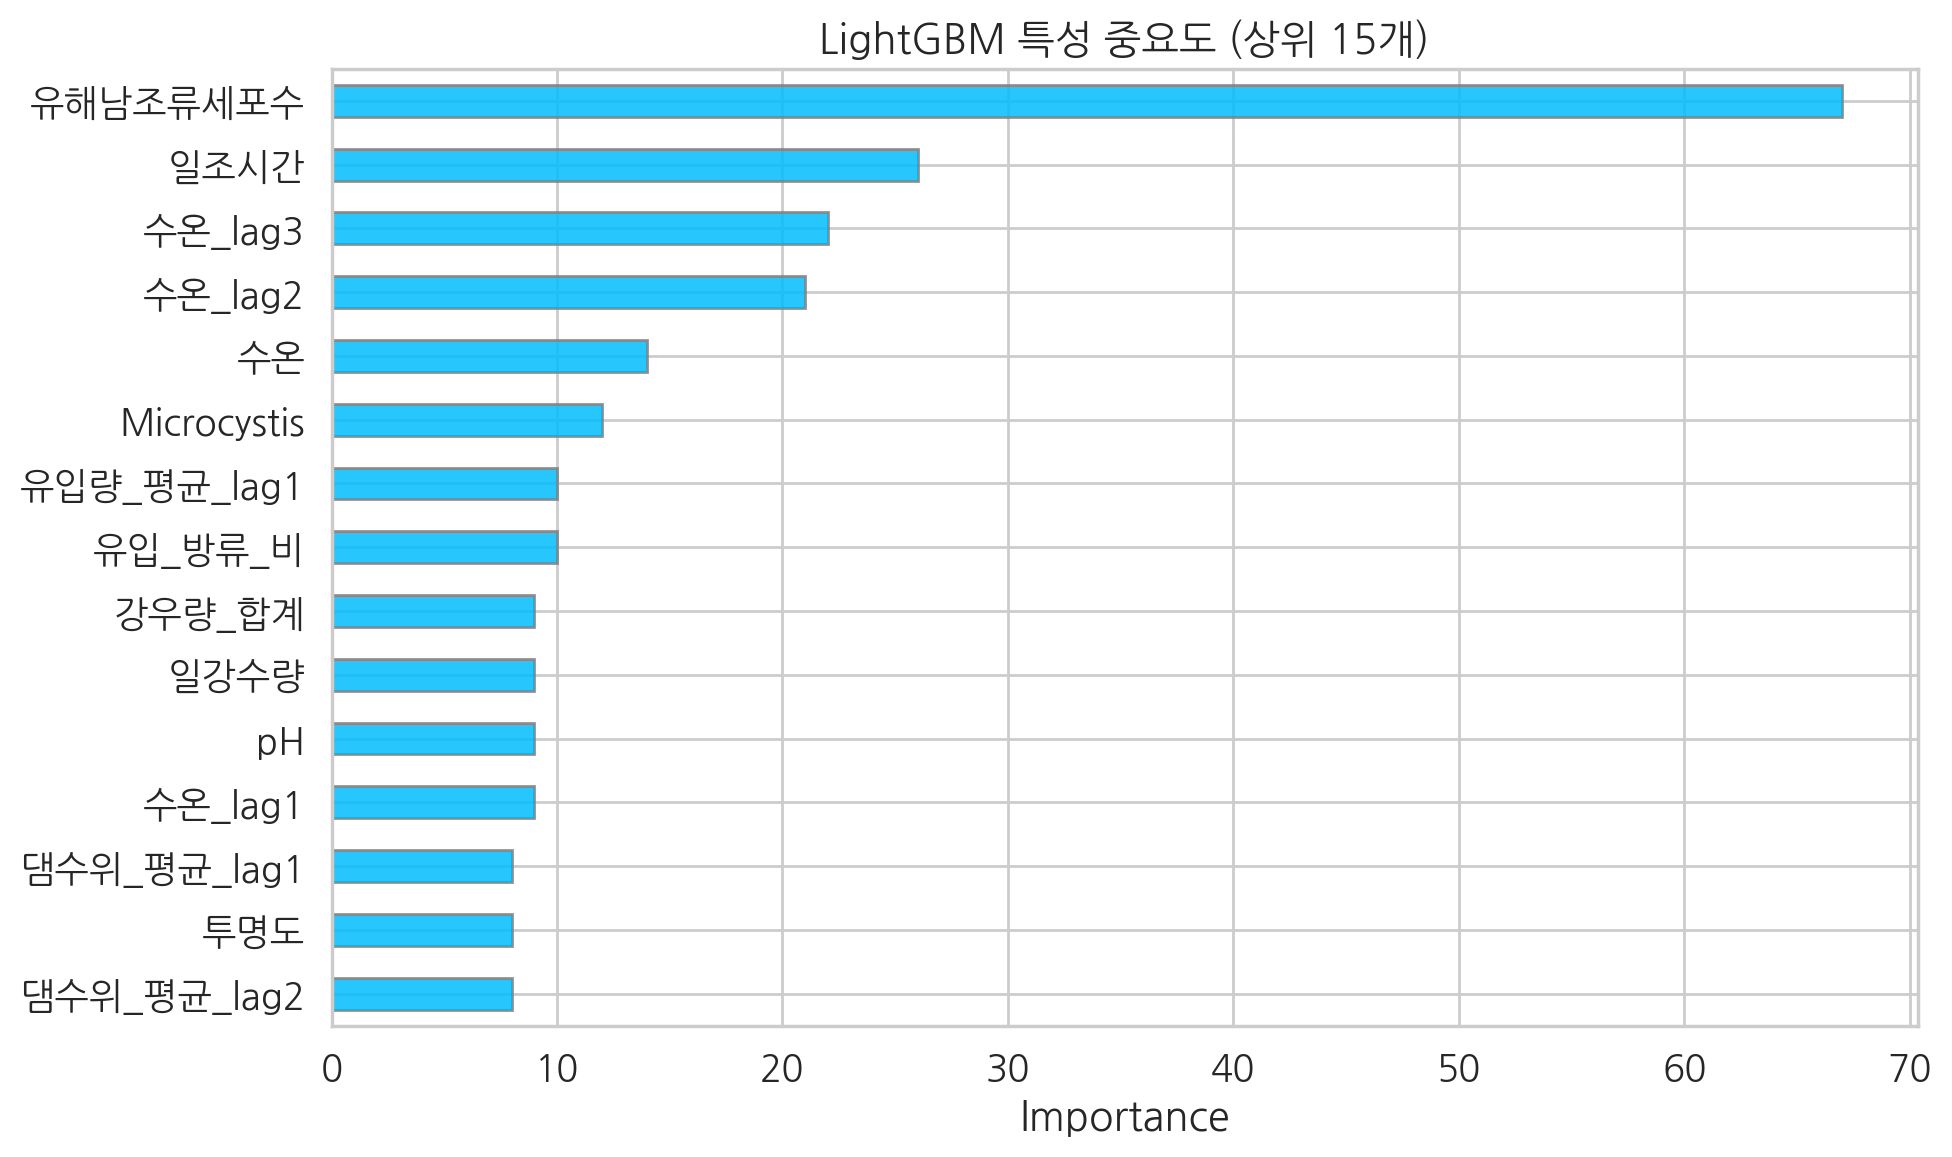

In [ ]:
#LightGBM 특성 중요도
feat_imp = pd.Series(lgb_model.feature_importances_, index=ALL_FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=False)

print("\n[LightGBM 상위 10개 중요 특성]")
print(feat_imp.head(10).round(1).to_string())

fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax_fi,
    color='#01BEFE', edgecolor='gray', alpha=0.85)
ax_fi.set_title('LightGBM 특성 중요도 (상위 15개)')
ax_fi.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ridge 메타 모델 (스태킹 앙상블 결합)
# 학습셋: LSTM 예측 + LightGBM 예측 → Ridge가 최적 가중치 학습
meta_X_train = np.column_stack([lstm_train_pred, lgb_train_pred])
meta_y_train = lstm_train_true

meta_X_test  = np.column_stack([lstm_test_pred,  lgb_test_pred])
meta_y_test  = lstm_test_true

# 학습셋 RMSE 기반 자동 가중치 계산 (성능 좋은 모델에 더 높은 가중치)
rmse_lstm_tr = np.sqrt(np.mean((lstm_train_pred - lstm_train_true)**2))
rmse_lgb_tr  = np.sqrt(np.mean((lgb_train_pred  - lstm_train_true)**2))

w_lstm = 1 / (rmse_lstm_tr + 1e-9)
w_lgb  = 1 / (rmse_lgb_tr  + 1e-9)
w_total = w_lstm + w_lgb

w_lstm_norm = w_lstm / w_total
w_lgb_norm  = w_lgb  / w_total

ensemble_pred = np.clip(
    lstm_test_pred * w_lstm_norm + lgb_test_pred * w_lgb_norm, 0, None
)

print(f"\n가중치 — LSTM: {w_lstm_norm:.3f}  LightGBM: {w_lgb_norm:.3f}")
print(f"(학습셋 RMSE — LSTM: {rmse_lstm_tr:.1f}  LightGBM: {rmse_lgb_tr:.1f})")


가중치 — LSTM: 0.440  LightGBM: 0.560
(학습셋 RMSE — LSTM: 3732.5  LightGBM: 2928.7)


In [ ]:
# ── 날짜 인덱스 ───────────────────────────────────────────────────────────────
min_len      = min(len(ensemble_pred), len(ensemble_true))
test_start   = len(df) - TEST_SIZE + SEQ_LENGTH
result_dates = df.index[test_start : test_start + min_len]

score_df = pd.DataFrame({
    'True'    : ensemble_true[:min_len],
    'LSTM'    : lstm_test_pred[:min_len],
    'LightGBM': lgb_test_pred[:min_len],
    'Ensemble': ensemble_pred[:min_len],
}, index=result_dates)

print(f"\n[예측 결과 테이블]")
print(score_df.round(0).to_string())

NameError: name 'ensemble_true' is not defined

In [ ]:
# ── 성능 지표 (모델 3개 비교) ─────────────────────────────────────────────────
ALERT_THRESHOLD = 1000

def metrics(true, pred, name):
    rmse  = np.sqrt(mean_squared_error(true, pred))
    mae   = mean_absolute_error(true, pred)
    ss_r  = ((pred - true)**2).sum()
    ss_t  = ((true - true.mean())**2).sum()
    r2    = 1 - ss_r / (ss_t + 1e-9)
    score = 100 * (1 - ss_r / ((true**2 + 1e-6).sum()))
    ta = (true >= ALERT_THRESHOLD).astype(int)
    pa = (pred >= ALERT_THRESHOLD).astype(int)
    acc = (ta == pa).mean() * 100
    return dict(name=name, RMSE=rmse, MAE=mae, R2=r2, Score=score, AlertAcc=acc)

results = [
    metrics(score_df['True'].values, score_df['LSTM'].values,     'LSTM'),
    metrics(score_df['True'].values, score_df['LightGBM'].values, 'LightGBM'),
    metrics(score_df['True'].values, score_df['Ensemble'].values, 'Ensemble'),
]
res_df = pd.DataFrame(results).set_index('name')

print("\n" + "="*65)
print("모델 성능 비교 (7일 선행 예측, 추동 지점)")
print("="*65)
print(f"  {'모델':<12} {'RMSE':>8} {'MAE':>8} {'R²':>7} {'경보적중(%)':>11}")
print("-"*65)
for nm, row in res_df.iterrows():
    marker = " ★" if nm == 'Ensemble' else ""
    print(f"  {nm:<12} {row['RMSE']:>8.1f} {row['MAE']:>8.1f} {row['R2']:>7.4f} {row['AlertAcc']:>10.1f}{marker}")
print("="*65)

true_alert = (score_df['True']     >= ALERT_THRESHOLD).astype(int)
pred_alert = (score_df['Ensemble'] >= ALERT_THRESHOLD).astype(int)
print("\n  [앙상블 조류경보 발령 예측 (관심 기준: ≥1,000 cells/㎖)]")
print(classification_report(true_alert, pred_alert,
                             target_names=['미발령', '관심'], zero_division=0))


모델 성능 비교 (7일 선행 예측, 추동 지점)
  모델               RMSE      MAE      R²     경보적중(%)
-----------------------------------------------------------------
  LSTM           3564.0   2183.1 -0.1207      100.0
  LightGBM       1620.8   1425.3  0.7682       83.3
  Ensemble       1989.8   1258.2  0.6507       83.3 ★

  [앙상블 조류경보 발령 예측 (관심 기준: ≥1,000 cells/㎖)]
              precision    recall  f1-score   support

         미발령       1.00      0.67      0.80         3
          관심       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



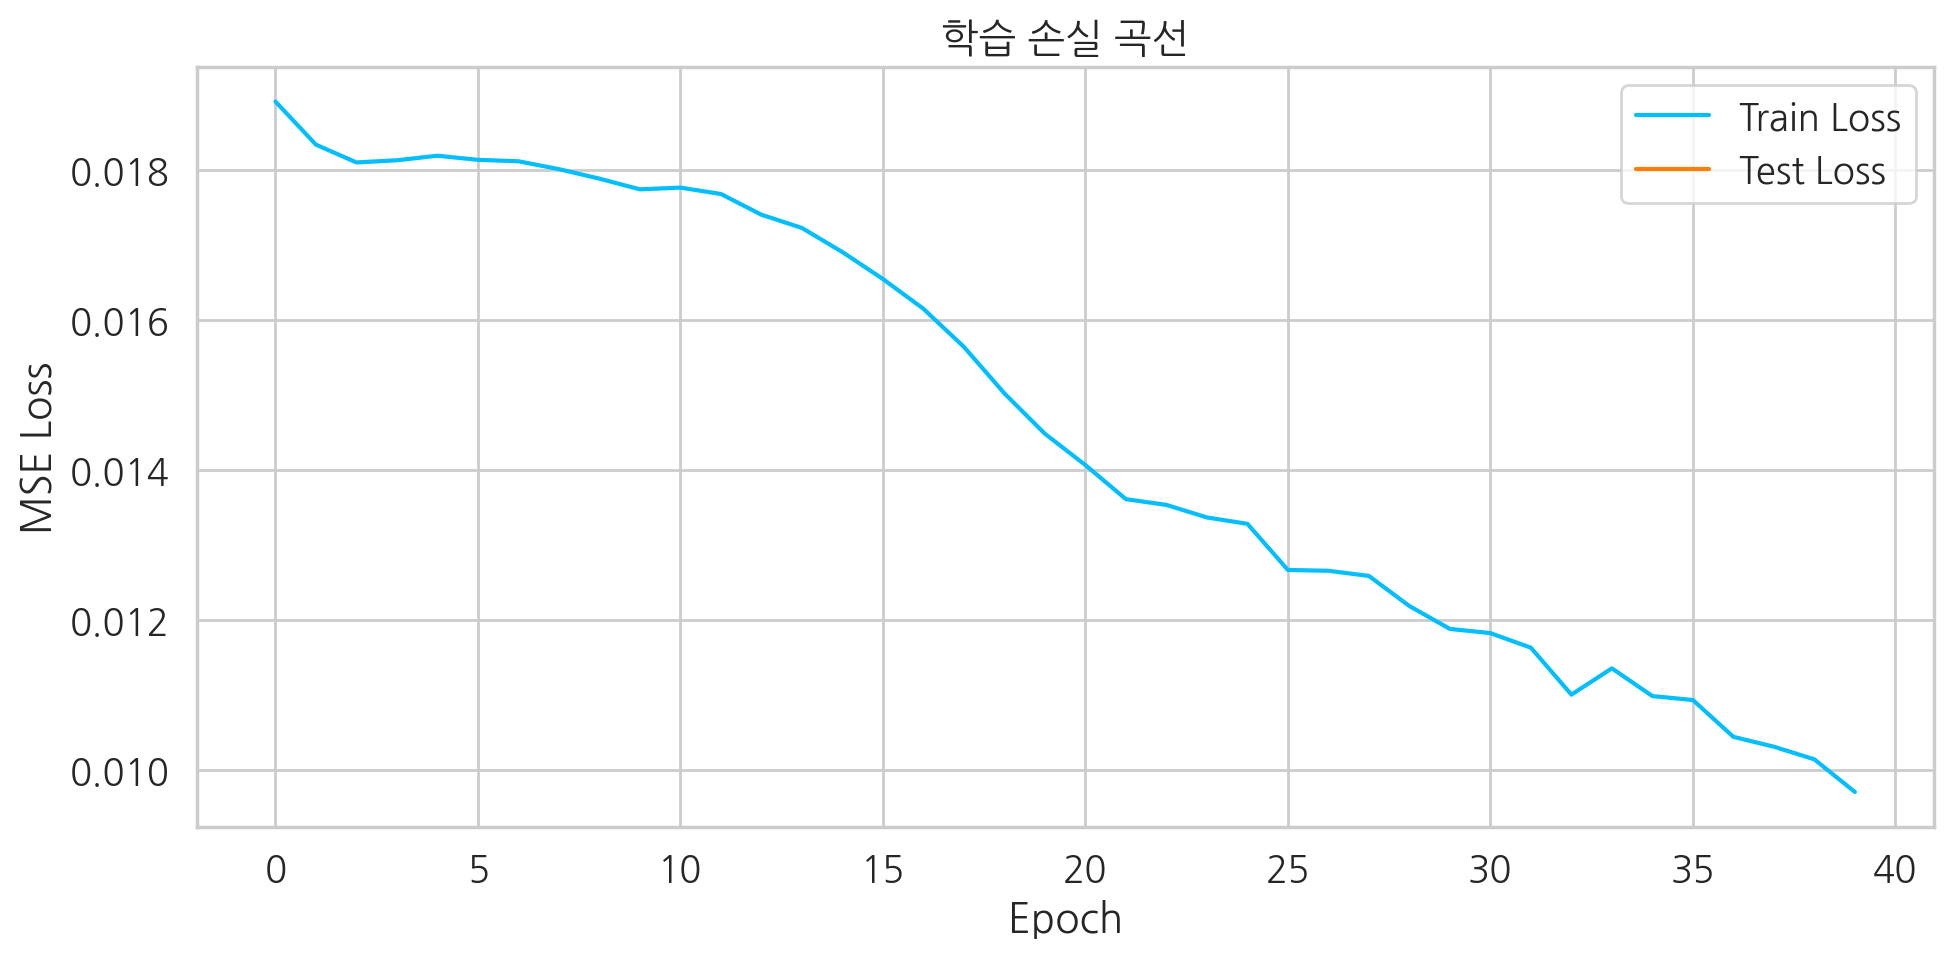

In [ ]:
# ── 11. 시각화 ────────────────────────────────────────────────────────────────

# ── 11-1. 학습 손실 곡선 ──────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_hist, label='Train Loss', color='#01BEFE', linewidth=1.5)
ax1.plot(test_hist,  label='Test Loss',  color='#FF7D00', linewidth=1.5)
ax1.set_title('학습 손실 곡선')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

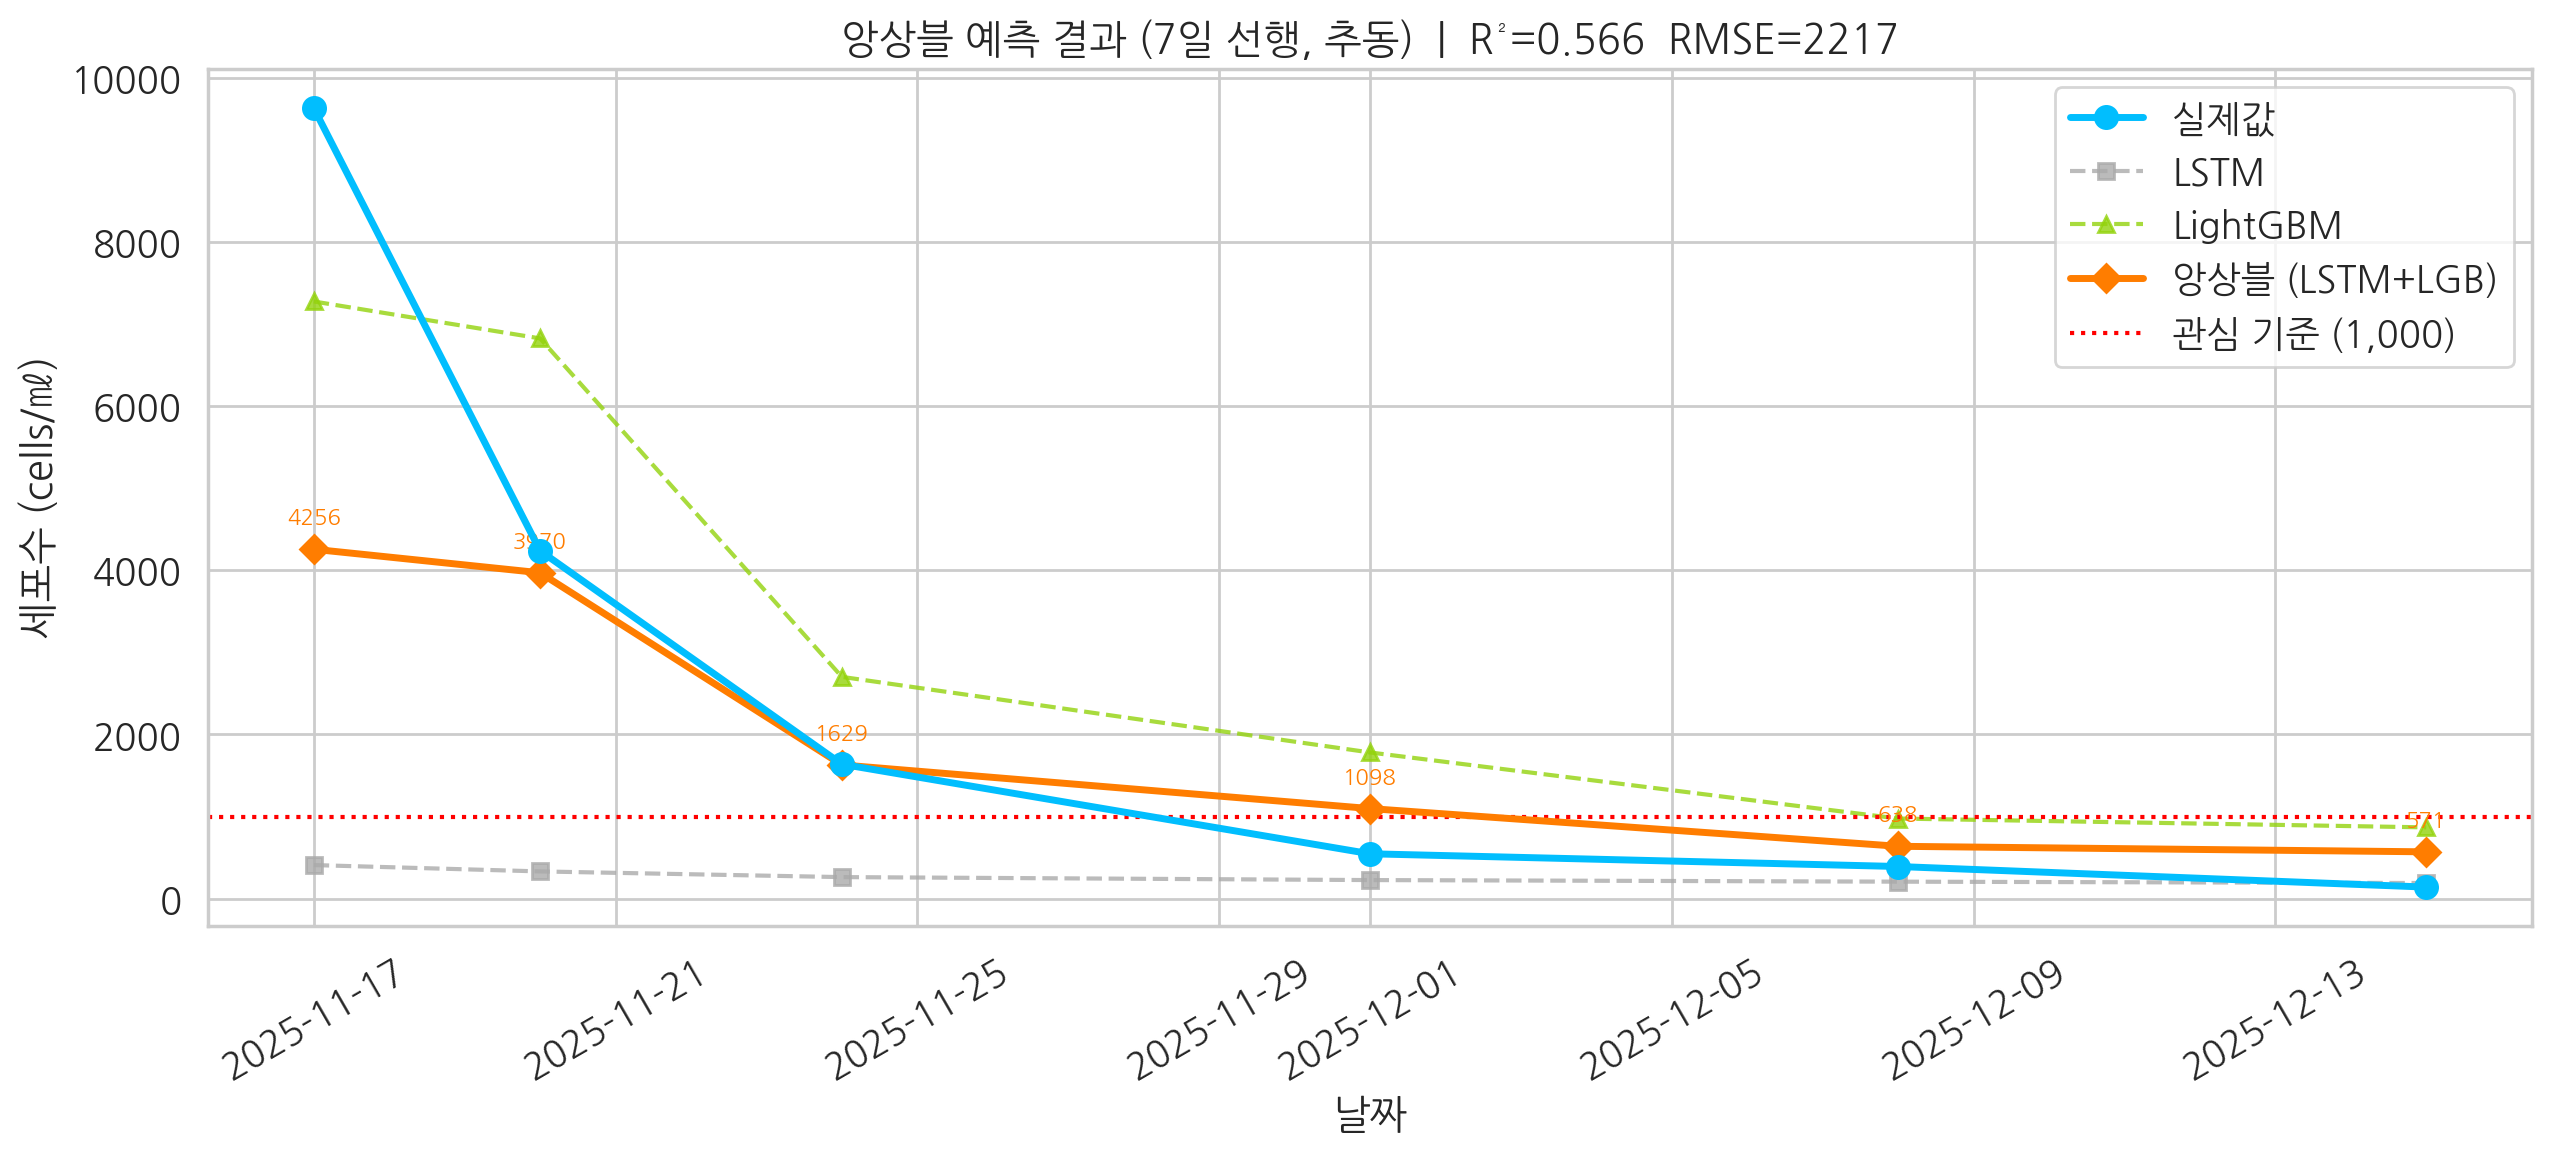

In [ ]:
# 11-2. 3개 모델 예측값 비교
fig2, ax2 = plt.subplots(figsize=(13, 6))
ax2.plot(score_df.index, score_df['True'],     marker='o', color='#01BEFE',
         linewidth=2.5, markersize=8, label='실제값', zorder=5)
ax2.plot(score_df.index, score_df['LSTM'],     marker='s', color='#AAAAAA',
         linewidth=1.5, markersize=6, linestyle='--', label='LSTM', alpha=0.8)
ax2.plot(score_df.index, score_df['LightGBM'], marker='^', color='#93D30C',
         linewidth=1.5, markersize=6, linestyle='--', label='LightGBM', alpha=0.8)
ax2.plot(score_df.index, score_df['Ensemble'], marker='D', color='#FF7D00',
         linewidth=2.5, markersize=7, linestyle='-',  label='앙상블 (LSTM+LGB)', zorder=4)
ax2.axhline(y=ALERT_THRESHOLD, color='red', linestyle=':', linewidth=1.5,
            label=f'관심 기준 ({ALERT_THRESHOLD:,})')
for d, row in score_df.iterrows():
    ax2.annotate(f"{row['Ensemble']:.0f}", (d, row['Ensemble']),
                 textcoords='offset points', xytext=(0, 9),
                 fontsize=8, color='#FF7D00', ha='center', fontweight='bold')
ax2.set_title(f"앙상블 예측 결과 (7일 선행, 추동)  |  R²={res_df.loc['Ensemble','R2']:.3f}  RMSE={res_df.loc['Ensemble','RMSE']:.0f}")
ax2.set_xlabel('날짜')
ax2.set_ylabel('세포수 (cells/㎖)')
ax2.legend(loc='upper right')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('ensemble_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#AAAAAA', '#93D30C', '#FF7D00']
labels = ['LSTM', 'LightGBM', '앙상블']

axes3[0].bar(labels, res_df['RMSE'], color=colors, edgecolor='gray', alpha=0.85)
axes3[0].set_title('RMSE 비교 (낮을수록 좋음)')
axes3[0].set_ylabel('cells/㎖')
for i, v in enumerate(res_df['RMSE']):
    axes3[0].text(i, v + 20, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes3[1].bar(labels, res_df['R2'], color=colors, edgecolor='gray', alpha=0.85)
axes3[1].set_title('R² 비교 (높을수록 좋음)')
axes3[1].set_ylim(0, 1.1)
for i, v in enumerate(res_df['R2']):
    axes3[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

axes3[2].bar(labels, res_df['AlertAcc'], color=colors, edgecolor='gray', alpha=0.85)
axes3[2].set_title('경보 발령 적중률 (높을수록 좋음)')
axes3[2].set_ylabel('%')
axes3[2].set_ylim(0, 115)
for i, v in enumerate(res_df['AlertAcc']):
    axes3[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('LSTM vs LightGBM vs 앙상블 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 11-3. 전체 시계열
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['유해남조류세포수'], color='#93D30C',
        alpha=0.7, linewidth=1, label='유해남조류 세포수 (실측)')

alert_idx = df[df['발령단계_num'] >= 1].index
if len(alert_idx):
    ax.scatter(alert_idx, df.loc[alert_idx, '유해남조류세포수'],
               color='red', zorder=5, s=15, label='관심 발령 시점')

ax.axhline(y=ALERT_THRESHOLD, color='red', linestyle=':', linewidth=1.5,
           label='관심 경보 기준')
ax.set_title('대청호 추동 - 유해남조류 세포수 전체 시계열 (2016~2025)')
ax.set_xlabel('날짜')
ax.set_ylabel('세포수 (cells/㎖)')
ax.legend()
plt.tight_layout()
plt.savefig('full_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'axes3' is not defined

KeyError: "['유해남조류세포수', '수온', '탁도', '댐수위_평균', '강우량_합계', '유입량_평균', '일조시간'] not in index"

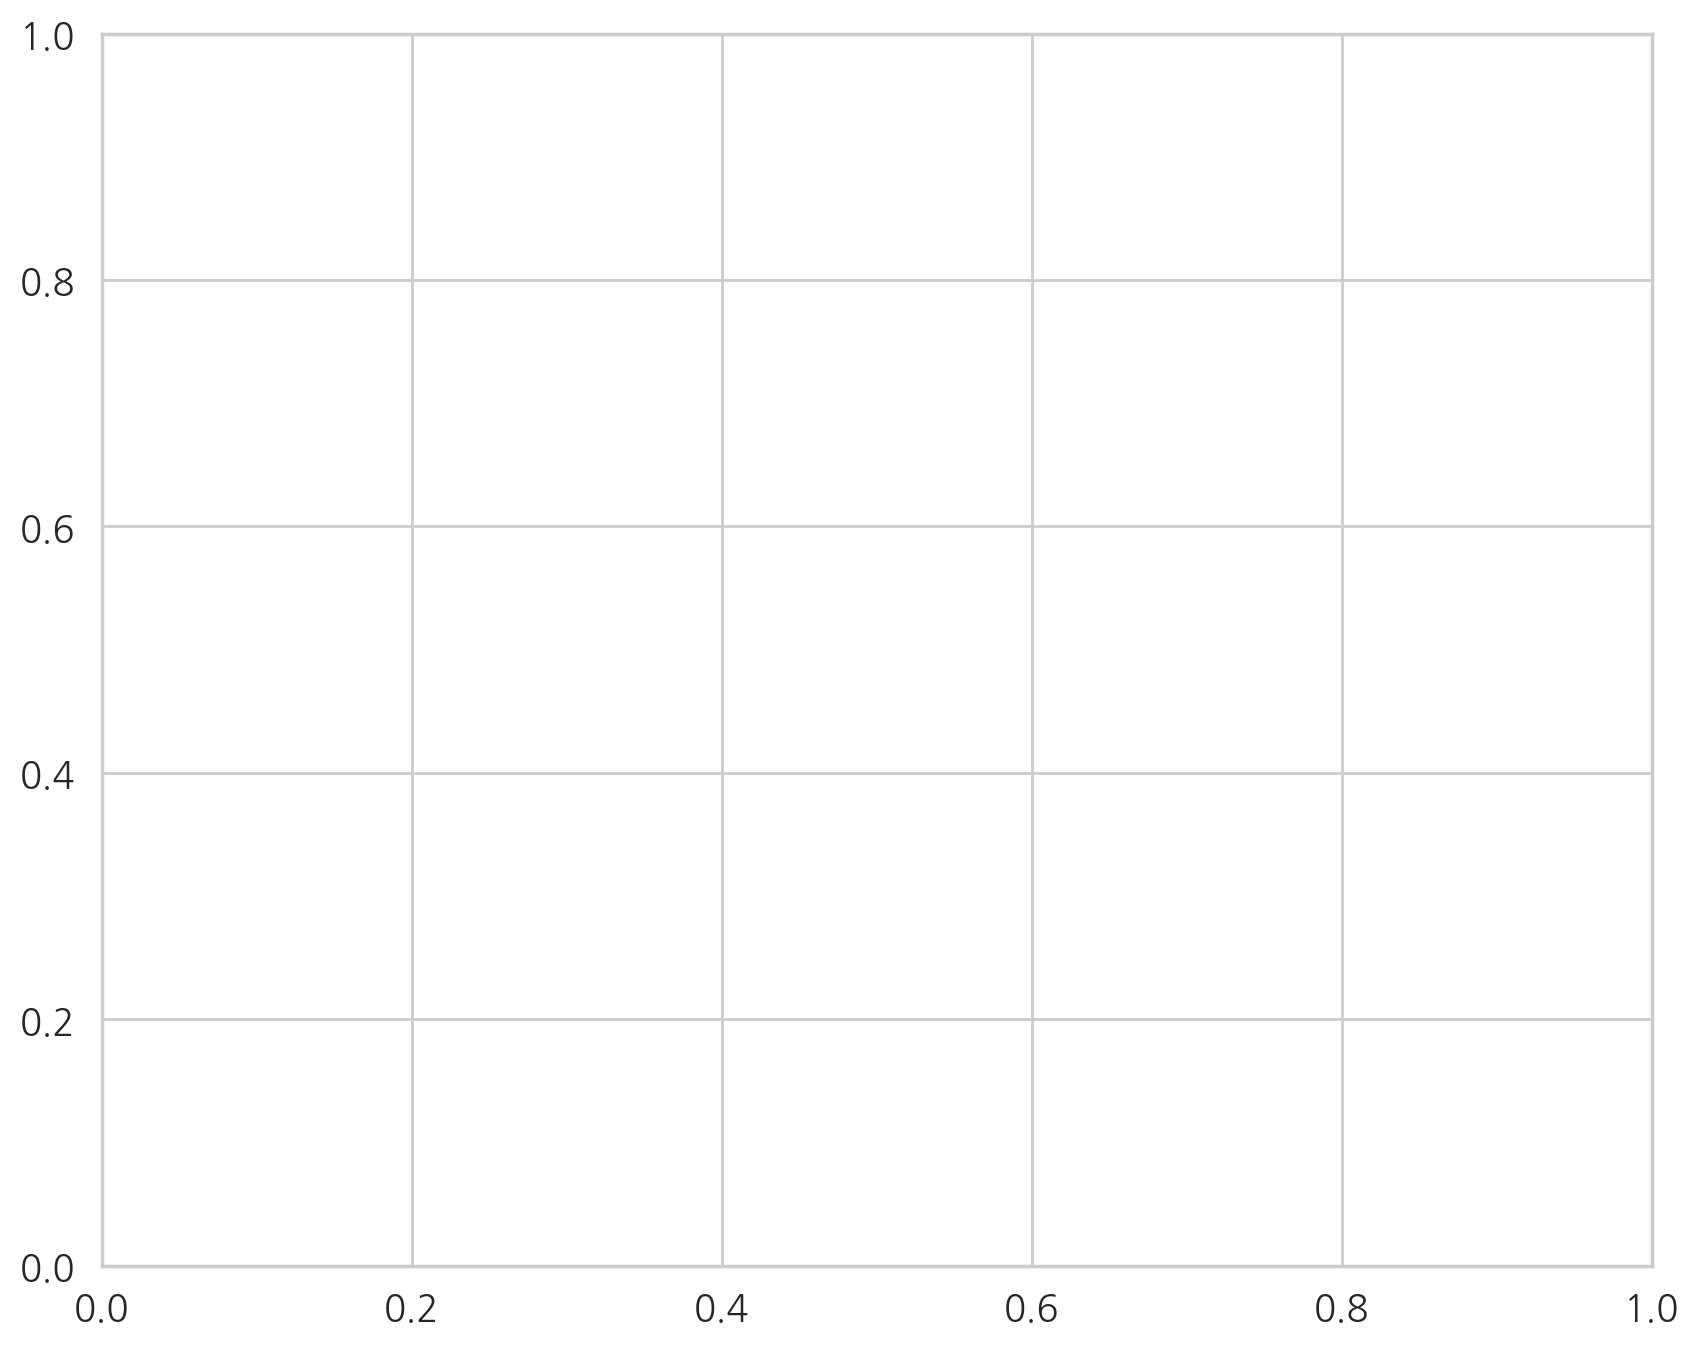

In [ ]:
# 11-4. 상관관계 히트맵
corr_cols = ['유해남조류세포수', '수온', 'Chl_a', 'DO', '탁도',
             '댐수위_평균', '강우량_합계', '유입량_평균', '일조시간']
fig, ax = plt.subplots(figsize=(10, 8))
corr_mat = df[corr_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('주요 변수 간 상관관계 (녹조 영향 인자 분석)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f"TEST_SIZE = {TEST_SIZE}")
print(f"테스트 기간: {df.index[-TEST_SIZE]} ~ {df.index[-1]}")

TEST_SIZE = 14
테스트 기간: 2025-10-20 00:00:00 ~ 2025-12-15 00:00:00


In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


In [ ]:
import subprocess, os, glob

# 1) 나눔고딕 패키지 설치
subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)
print("fonts-nanum 설치 완료")

# 2) matplotlib 폰트 캐시 전체 삭제 (새 폰트 인식을 위해 필수)
import matplotlib
cache_dir = matplotlib.get_cachedir()
for f in glob.glob(os.path.join(cache_dir, 'font*')):
    os.remove(f)
print(f"폰트 캐시 삭제: {cache_dir}")

# 3) 설치 확인
result = subprocess.run(['fc-list', ':lang=ko', '--format=%{family}\n'],
                        capture_output=True, text=True)
nanum_fonts = [l for l in result.stdout.splitlines() if 'Nanum' in l]
print(f"설치된 나눔 폰트: {nanum_fonts[:3]}")
print("\n 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!")
print("   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.")

fonts-nanum 설치 완료
폰트 캐시 삭제: /root/.cache/matplotlib
설치된 나눔 폰트: ['NanumGothic,나눔고딕', 'NanumMyeongjo,나눔명조', 'NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold']

 여기까지 실행 후 [런타임 → 런타임 다시 시작] 하세요!
   재시작 후 이 셀은 건너뛰고 아래 셀부터 실행하면 됩니다.


In [ ]:
import subprocess, glob, os
import matplotlib as mpl
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'], check=True)

# 캐시 무시하고 강제 재스캔 ← 이게 핵심
fm._load_fontmanager(try_read_cache=False)

nanum_files = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if nanum_files:
    _fp   = fm.FontProperties(fname=nanum_files[0])
    _name = _fp.get_name()
    mpl.rcParams['font.family']        = _name
    mpl.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 적용: '{_name}'")
else:
    print("NanumGothic.ttf 없음 — apt-get install fonts-nanum 확인")

한글 폰트 적용: 'NanumGothic'


In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

# 설치된 나눔 폰트 파일 확인
font_paths = glob.glob("/usr/share/fonts/truetype/nanum/*.ttf")
print(font_paths)

# 파일 경로 직접 지정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", font=font_name)

print("적용된 폰트:", font_name)

['/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf']
적용된 폰트: NanumGothic


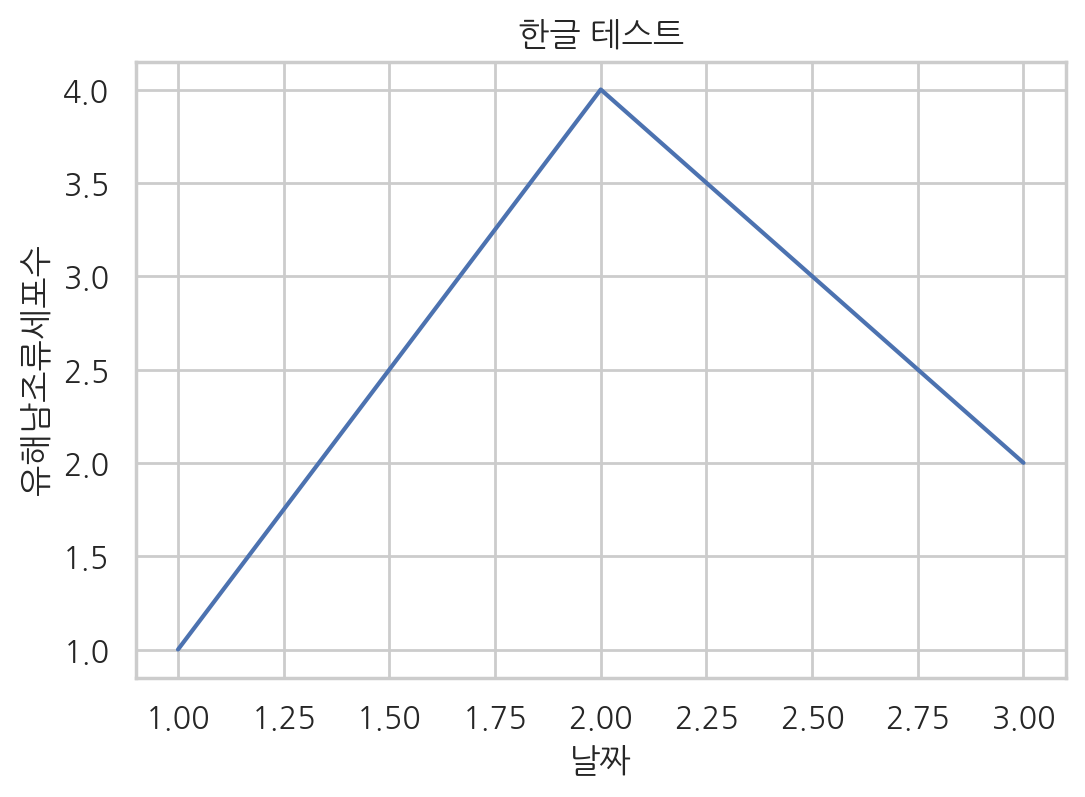

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [1, 4, 2])
plt.title("한글 테스트")
plt.xlabel("날짜")
plt.ylabel("유해남조류세포수")
plt.show()

In [ ]:
# ── 라이브러리 ────────────────────────────────────────────────────────────────
import warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing          import MinMaxScaler
from sklearn.model_selection        import StratifiedKFold, GridSearchCV
from sklearn.metrics                import (accuracy_score, confusion_matrix,
                                            classification_report)
from imblearn.over_sampling         import RandomOverSampler
from xgboost                        import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
MONITORING_PATH = '/content/대청호_조류모니터링_일자료.csv'
DAM_OPS_PATH = '/content/운영정보.csv'

In [ ]:
# 1. 데이터 로드 및 전처리
print("\n" + "="*60)
print("1. 데이터 로드")
print("="*60)

df_mon = pd.read_csv(MONITORING_PATH, encoding='utf-8-sig')
df_dam = pd.read_csv(DAM_OPS_PATH,    encoding='utf-8-sig')


1. 데이터 로드


In [ ]:
df = df_mon[df_mon['채수위치'] == '추동'].copy().reset_index(drop=True)

In [ ]:
HA_COL = '유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4)'
df = df.rename(columns={
    '조사일'          : 'Date',
    '일조시간 합계(hr)' : 'Duration_of_Sunshine',
    '수온(℃)'         : 'WT',
    'pH'              : 'pH',
    'DO(㎎/L)'        : 'DO',
    '투명도'          : 'Transparency',
    '탁도'            : 'Turb',
    'Chl-a (㎎/㎥)'  : 'Chl_a',
    '발령단계'        : 'Alert_Level',
    HA_COL            : 'HA_Cells',
})
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df_dam = df_dam.rename(columns={
    '일시'          : 'Date',
    '저수율(%)'     : 'Vol',
    '강우량(mm)'    : 'Rain_dam',
    '총방류량(㎥/s)': 'Total_Discharge',
})
df_dam['Date'] = pd.to_datetime(df_dam['Date'])

In [ ]:
rain_7d = []
for date in df['Date']:
    mask = (df_dam['Date'] >= date - pd.Timedelta(days=6)) & \
           (df_dam['Date'] <= date)
    rain_7d.append(df_dam.loc[mask, 'Rain_dam'].sum())
df['Rain'] = rain_7d

In [ ]:
# 2. 조류경보 타겟 라벨링 (HA_Cells 기반)
print("\n" + "="*60)
print("2. 타겟 라벨링 (HA_Cells 기반)")
print("="*60)

df['target'] = 0
df.loc[df['HA_Cells'] >= 1_000,     'target'] = 1   # 관심
df.loc[df['HA_Cells'] >= 10_000,    'target'] = 2   # 경계
df.loc[df['HA_Cells'] >= 1_000_000, 'target'] = 3   # 대발생

print("  target 분포 (전체):")
for k, v in df['target'].value_counts().sort_index().items():
    lbl = {0:'미발령', 1:'관심', 2:'경계', 3:'대발생'}[k]
    print(f"    {k} ({lbl}): {v}건")


2. 타겟 라벨링 (HA_Cells 기반)
  target 분포 (전체):
    0 (미발령): 413건
    1 (관심): 91건
    2 (경계): 32건


In [ ]:
KEY_COLS = ['WT', 'DO', 'Chl_a', 'Transparency', 'Turb',
            'Rain', 'HA_Cells']
df = df.dropna(subset=KEY_COLS).reset_index(drop=True)
print(f"\n  결측 제거 후: {df.shape[0]}행")
print("  target 분포 (결측 제거 후):")
for k, v in df['target'].value_counts().sort_index().items():
    lbl = {0:'미발령', 1:'관심', 2:'경계', 3:'대발생'}[k]
    print(f"    {k} ({lbl}): {v}건")



  결측 제거 후: 515행
  target 분포 (결측 제거 후):
    0 (미발령): 392건
    1 (관심): 91건
    2 (경계): 32건


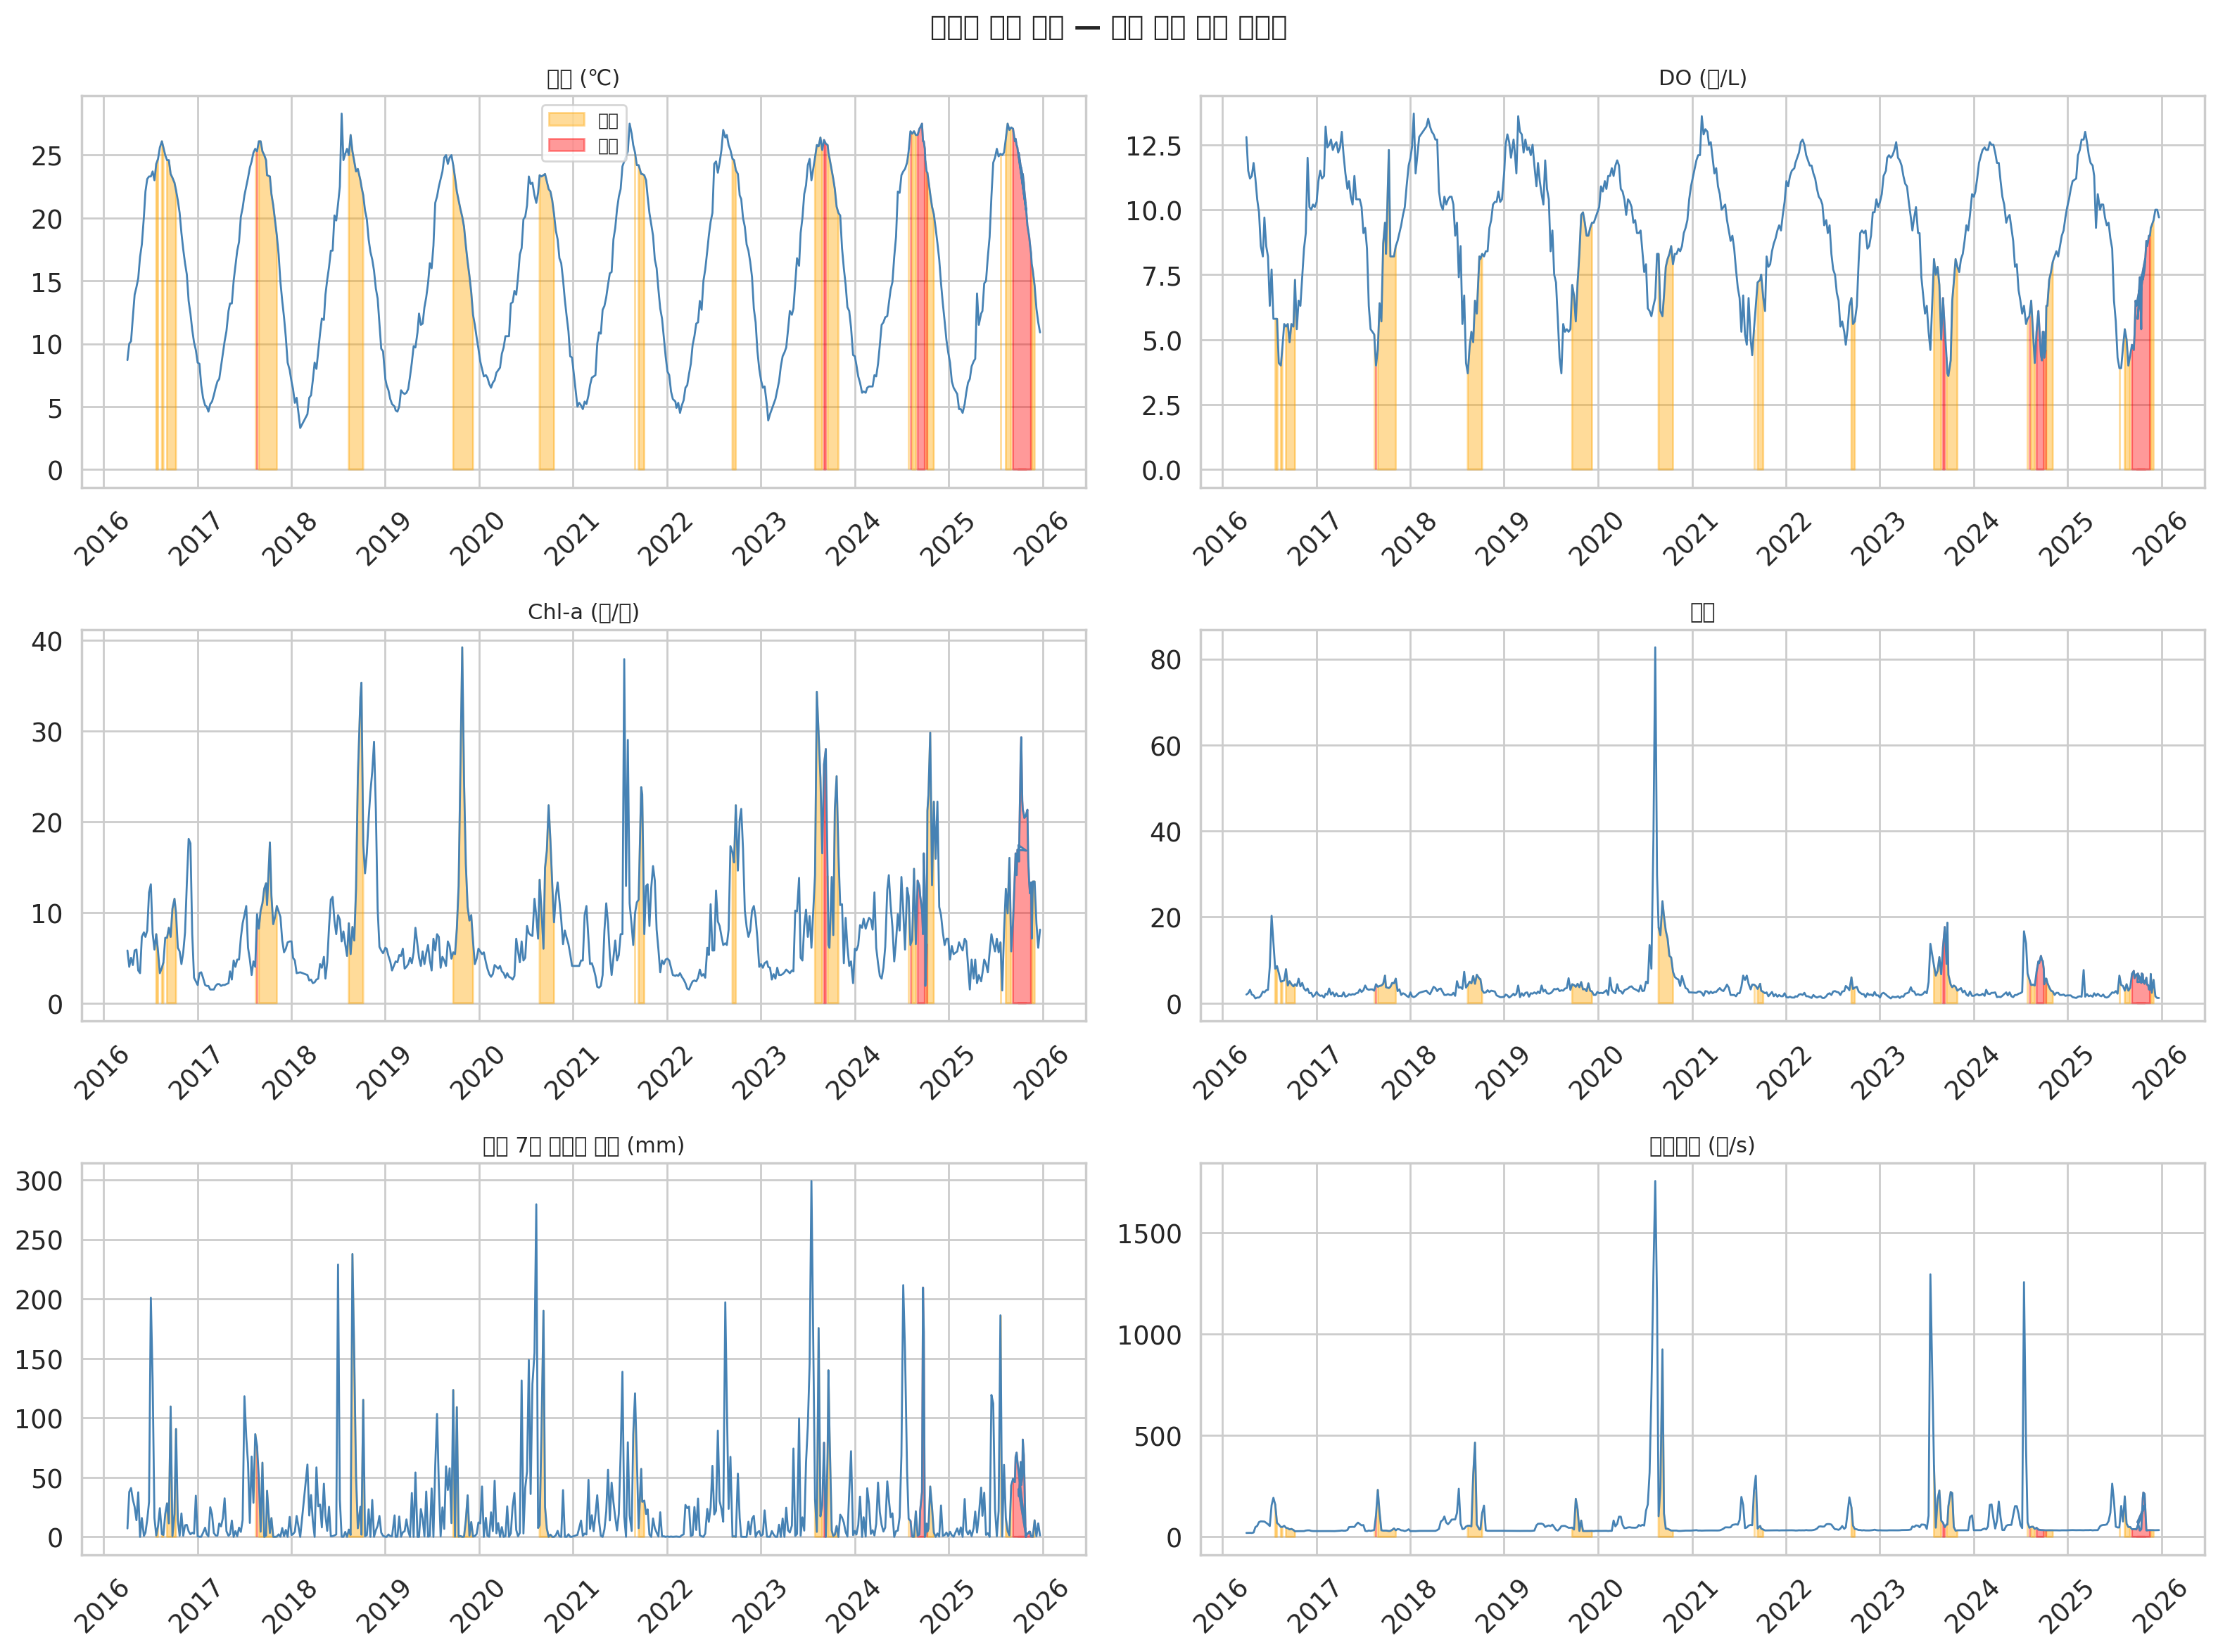

In [ ]:
# 3. 시계열 탐색적 시각화
print("="*60)

target_colors = {0:'green', 1:'orange', 2:'red', 3:'purple'}

# Calculate 7-day average of Total_Discharge and add it to df
# This part is added to resolve KeyError: 'Total_Discharge'
total_discharge_7d_avg = []
for date in df['Date']:
    # Consider 7 days *prior* to the current date, consistent with the original notebook's df_dam_agg logic
    window = df_dam[(df_dam['Date'] >= date - pd.Timedelta(days=7)) &
                    (df_dam['Date'] <  date)]
    if not window.empty:
        total_discharge_7d_avg.append(window['Total_Discharge'].mean())
    else:
        total_discharge_7d_avg.append(np.nan) # Append NaN if no data in window

df_temp = df.copy() # Create a temporary copy to avoid SettingWithCopyWarning
df_temp['Total_Discharge'] = total_discharge_7d_avg
# Fill NaNs that might occur at the beginning of the series due to the window
df_temp['Total_Discharge'] = df_temp['Total_Discharge'].fillna(method='ffill').fillna(method='bfill')
df = df_temp # Update the df to the modified one

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('대청호 추동 지점 — 주요 수질 변수 시계열', fontsize=14, fontweight='bold')

plot_vars = [
    ('WT',         '수온 (℃)'),
    ('DO',         'DO (㎎/L)'),
    ('Chl_a',      'Chl-a (㎎/㎥)'),
    ('Turb',       '탁도'),
    ('Rain',       '이전 7일 강우량 합계 (mm)'),
    ('Total_Discharge', '총방류량 (㎥/s)'),
]
for ax, (col, label) in zip(axes.flat, plot_vars):
    ax.plot(df['Date'], df[col], color='steelblue', lw=1)
    ax.fill_between(df['Date'], df[col],
                    where=(df['target'] == 1), color='orange', alpha=0.4, label='관심')
    ax.fill_between(df['Date'], df[col],
                    where=(df['target'] == 2), color='red',    alpha=0.4, label='경계')
    ax.set_title(label, fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    if col == 'WT':
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/01_timeseries.png', dpi=150, bbox_inches='tight')
plt.close()

In [ ]:
# 4. 이상치 확인 및 처리 (IQR)
print("\n" + "="*60)
print("4. 이상치 처리 (IQR)")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('이상치 처리 전 박스플롯', fontsize=12)
for ax, col in zip(axes, ['Turb', 'Chl_a', 'Total_Discharge']):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_outlier_before.png', dpi=150, bbox_inches='tight')
plt.close()

# Turb: target=0인 이상치만 upper_bound로 대체 (ipynb 동일)
Q1_t, Q3_t = df['Turb'].quantile([0.25, 0.75])
IQR_t = Q3_t - Q1_t
upper_t = Q3_t + 1.5 * IQR_t
print(f"  Turb  — Q1:{Q1_t:.2f}, Q3:{Q3_t:.2f}, IQR:{IQR_t:.2f}, 상한:{upper_t:.2f}")
n_replaced = ((df['Turb'] > upper_t) & (df['target'] == 0)).sum()
df.loc[(df['Turb'] > upper_t) & (df['target'] == 0), 'Turb'] = upper_t
print(f"  Turb 이상치 대체 (target=0): {n_replaced}건")

# Chl_a: 이상치를 평균값으로 대체 (ipynb 동일)
Q1_c, Q3_c = df['Chl_a'].quantile([0.25, 0.75])
IQR_c = Q3_c - Q1_c
upper_c = Q3_c + 1.5 * IQR_c
print(f"  Chl_a — Q1:{Q1_c:.2f}, Q3:{Q3_c:.2f}, IQR:{IQR_c:.2f}, 상한:{upper_c:.2f}")
outlier_idx_c = df[df['Chl_a'] > upper_c].index
if len(outlier_idx_c):
    mean_c = df.loc[outlier_idx_c, 'Chl_a'].mean()
    df.loc[outlier_idx_c, 'Chl_a'] = mean_c
    print(f"  Chl_a 이상치 평균대체: {len(outlier_idx_c)}건 → 평균값 {mean_c:.2f}")


4. 이상치 처리 (IQR)
  Turb  — Q1:1.90, Q3:4.10, IQR:2.20, 상한:7.40
  Turb 이상치 대체 (target=0): 12건
  Chl_a — Q1:4.30, Q3:10.50, IQR:6.20, 상한:19.80
  Chl_a 이상치 평균대체: 39건 → 평균값 25.47


In [ ]:
# 5. 파생 변수 생성: Turb_Transparency
print("="*60)
df['Turb_Transparency'] = df['Turb'] - df['Transparency']
print("  Turb_Transparency = Turb - Transparency 생성 완료")

# ── HA_Cells 컬럼 제거 ─────────────────────────────────────────────────────
df_clean = df.drop(columns=['HA_Cells'], errors='ignore')

  Turb_Transparency = Turb - Transparency 생성 완료


In [ ]:
# 6. 이진 타겟 생성 + Min-Max 정규화
print("="*60)

# 이진 분류 (0=미발령, 1=관심+경계+대발생)
df_clean['newlabel'] = df_clean['target'].replace({0:0, 1:1, 2:1, 3:1})
print("  이진 레이블 분포:")
print("   ", df_clean['newlabel'].value_counts().to_dict())

# 정규화 대상 컬럼
NORM_COLS = ['WT', 'pH', 'DO', 'Transparency', 'Turb', 'Chl_a',
             'Vol', 'Rain', 'Total_Discharge', 'Duration_of_Sunshine',
             'Turb_Transparency']
NORM_COLS = [c for c in NORM_COLS if c in df_clean.columns]

scaler  = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[NORM_COLS] = scaler.fit_transform(df_clean[NORM_COLS])
print(f"  정규화 완료: {NORM_COLS}")

  이진 레이블 분포:
    {0: 392, 1: 123}
  정규화 완료: ['WT', 'pH', 'DO', 'Transparency', 'Turb', 'Chl_a', 'Rain', 'Total_Discharge', 'Duration_of_Sunshine', 'Turb_Transparency']


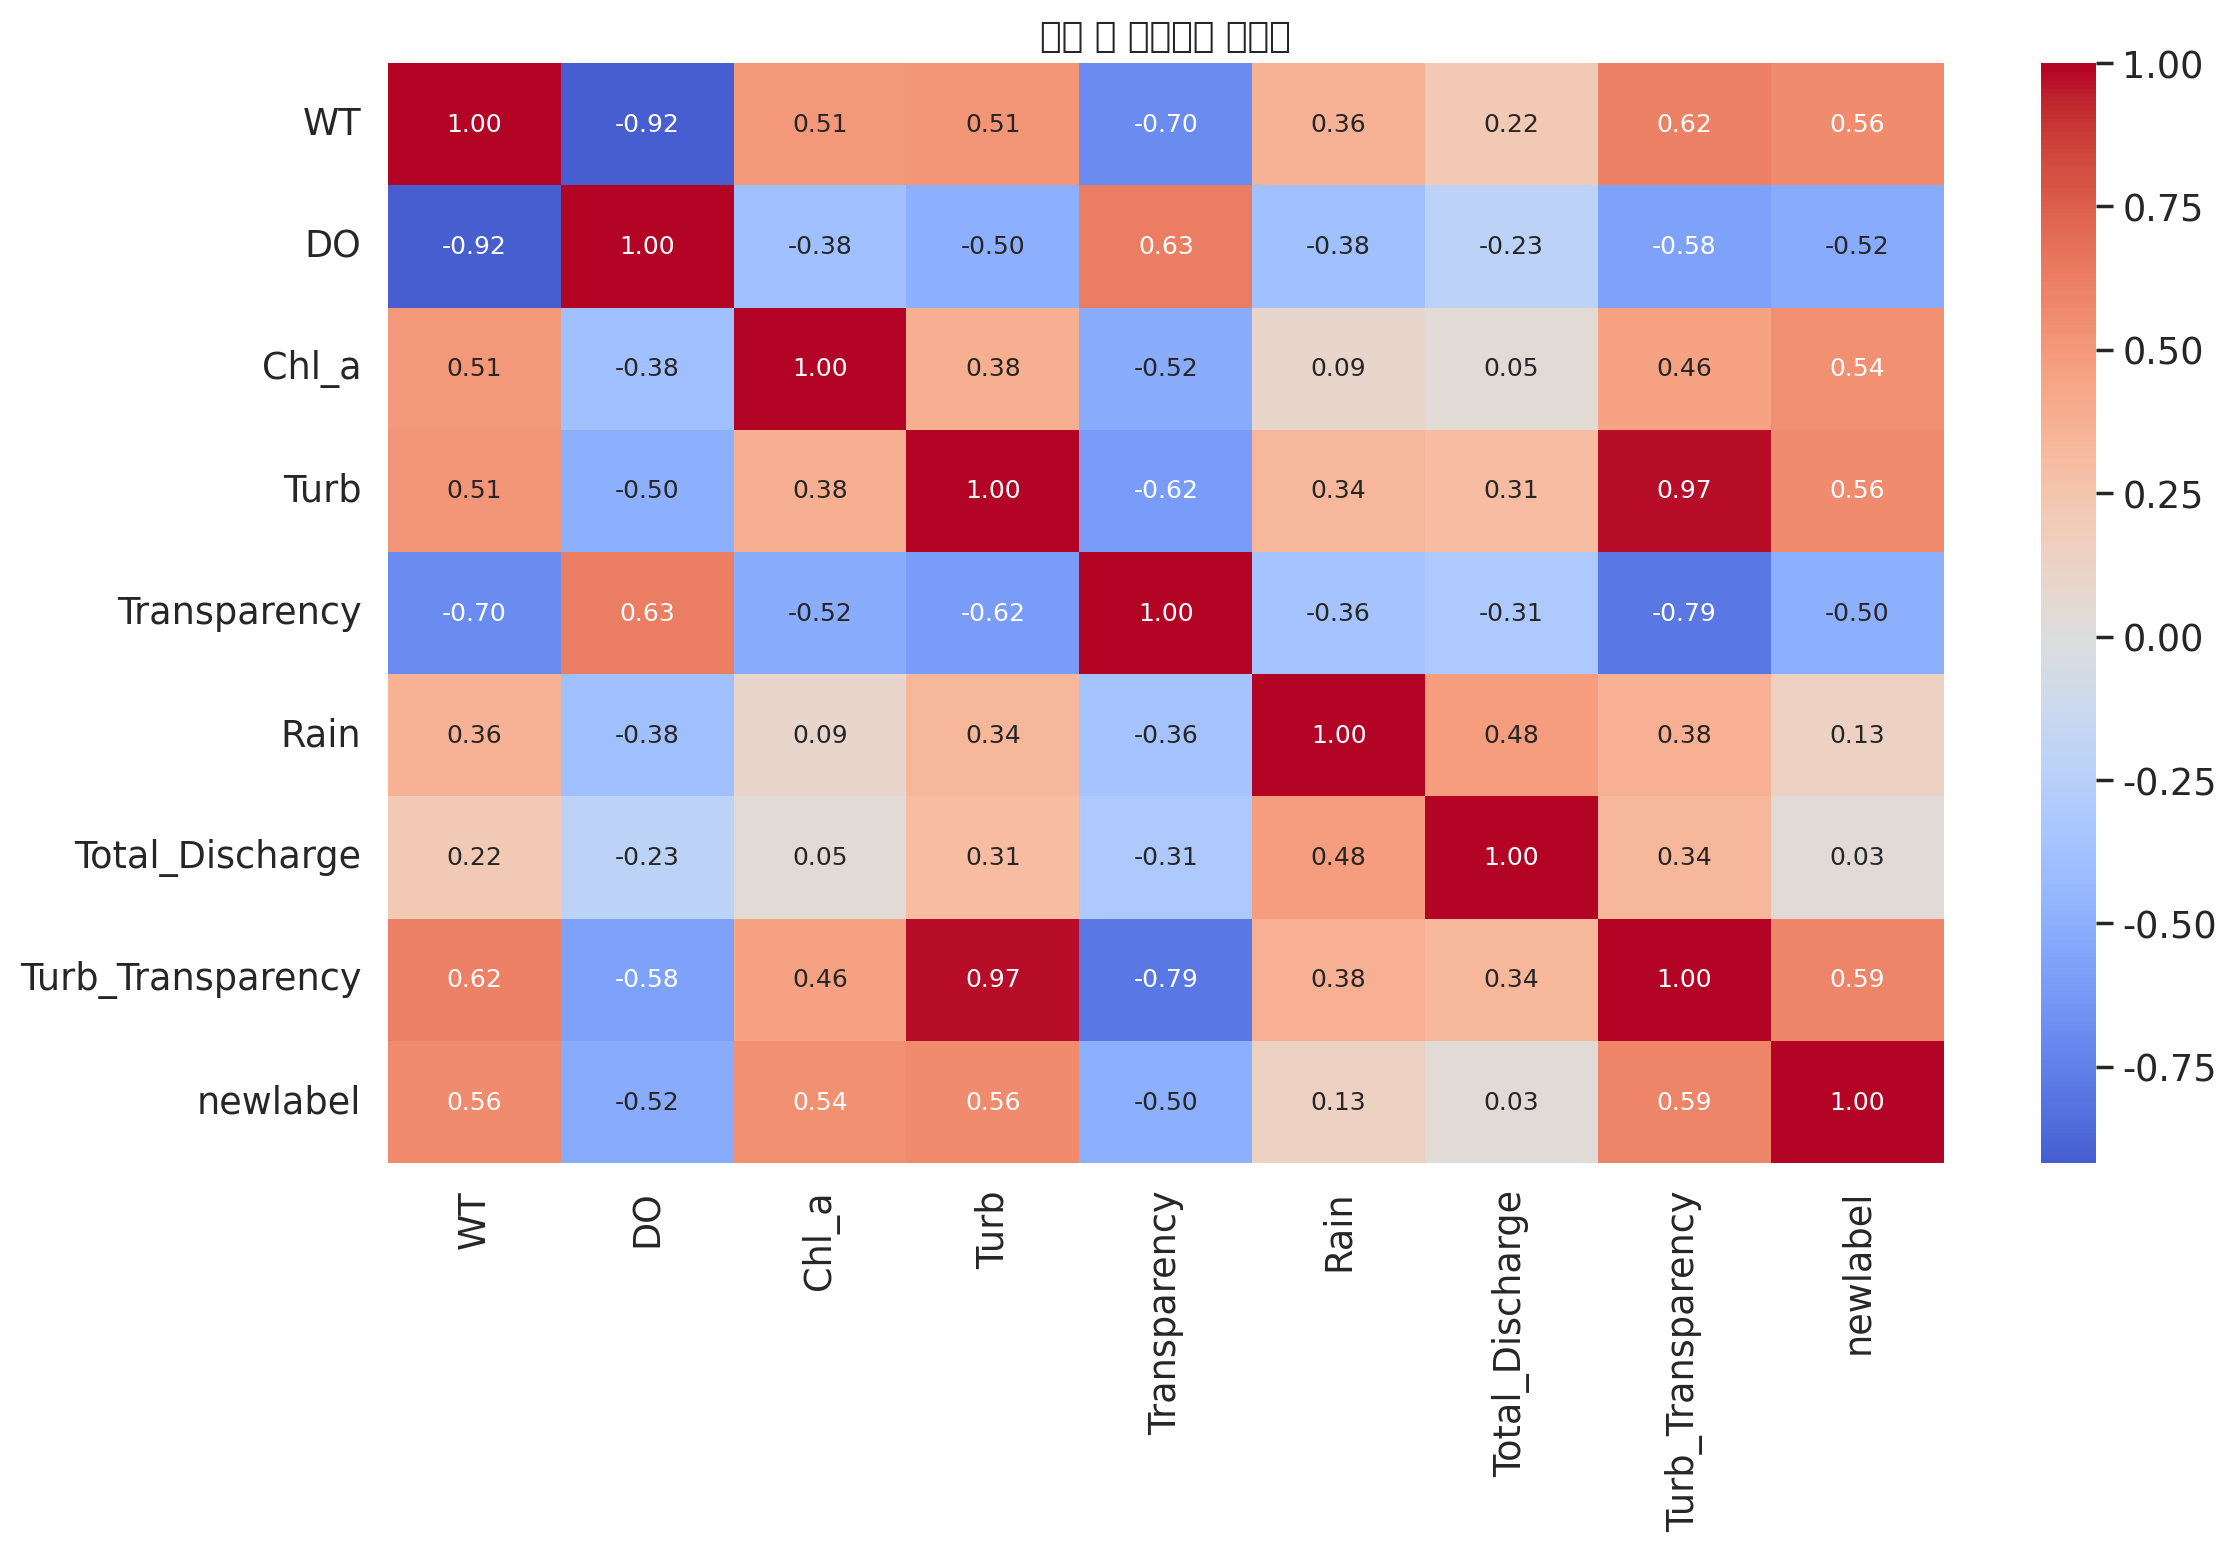

In [ ]:
# 7. 히트맵 (상관관계)
print("="*60)

NUMERIC_COLS = ['WT', 'DO', 'Chl_a', 'Turb', 'Transparency',
                'Rain', 'Total_Discharge', 'Vol', 'Turb_Transparency', 'newlabel']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df_norm.columns]

plt.figure(figsize=(12, 8))
corr = df_norm[NUMERIC_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 9})
plt.title('변수 간 상관관계 히트맵', fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

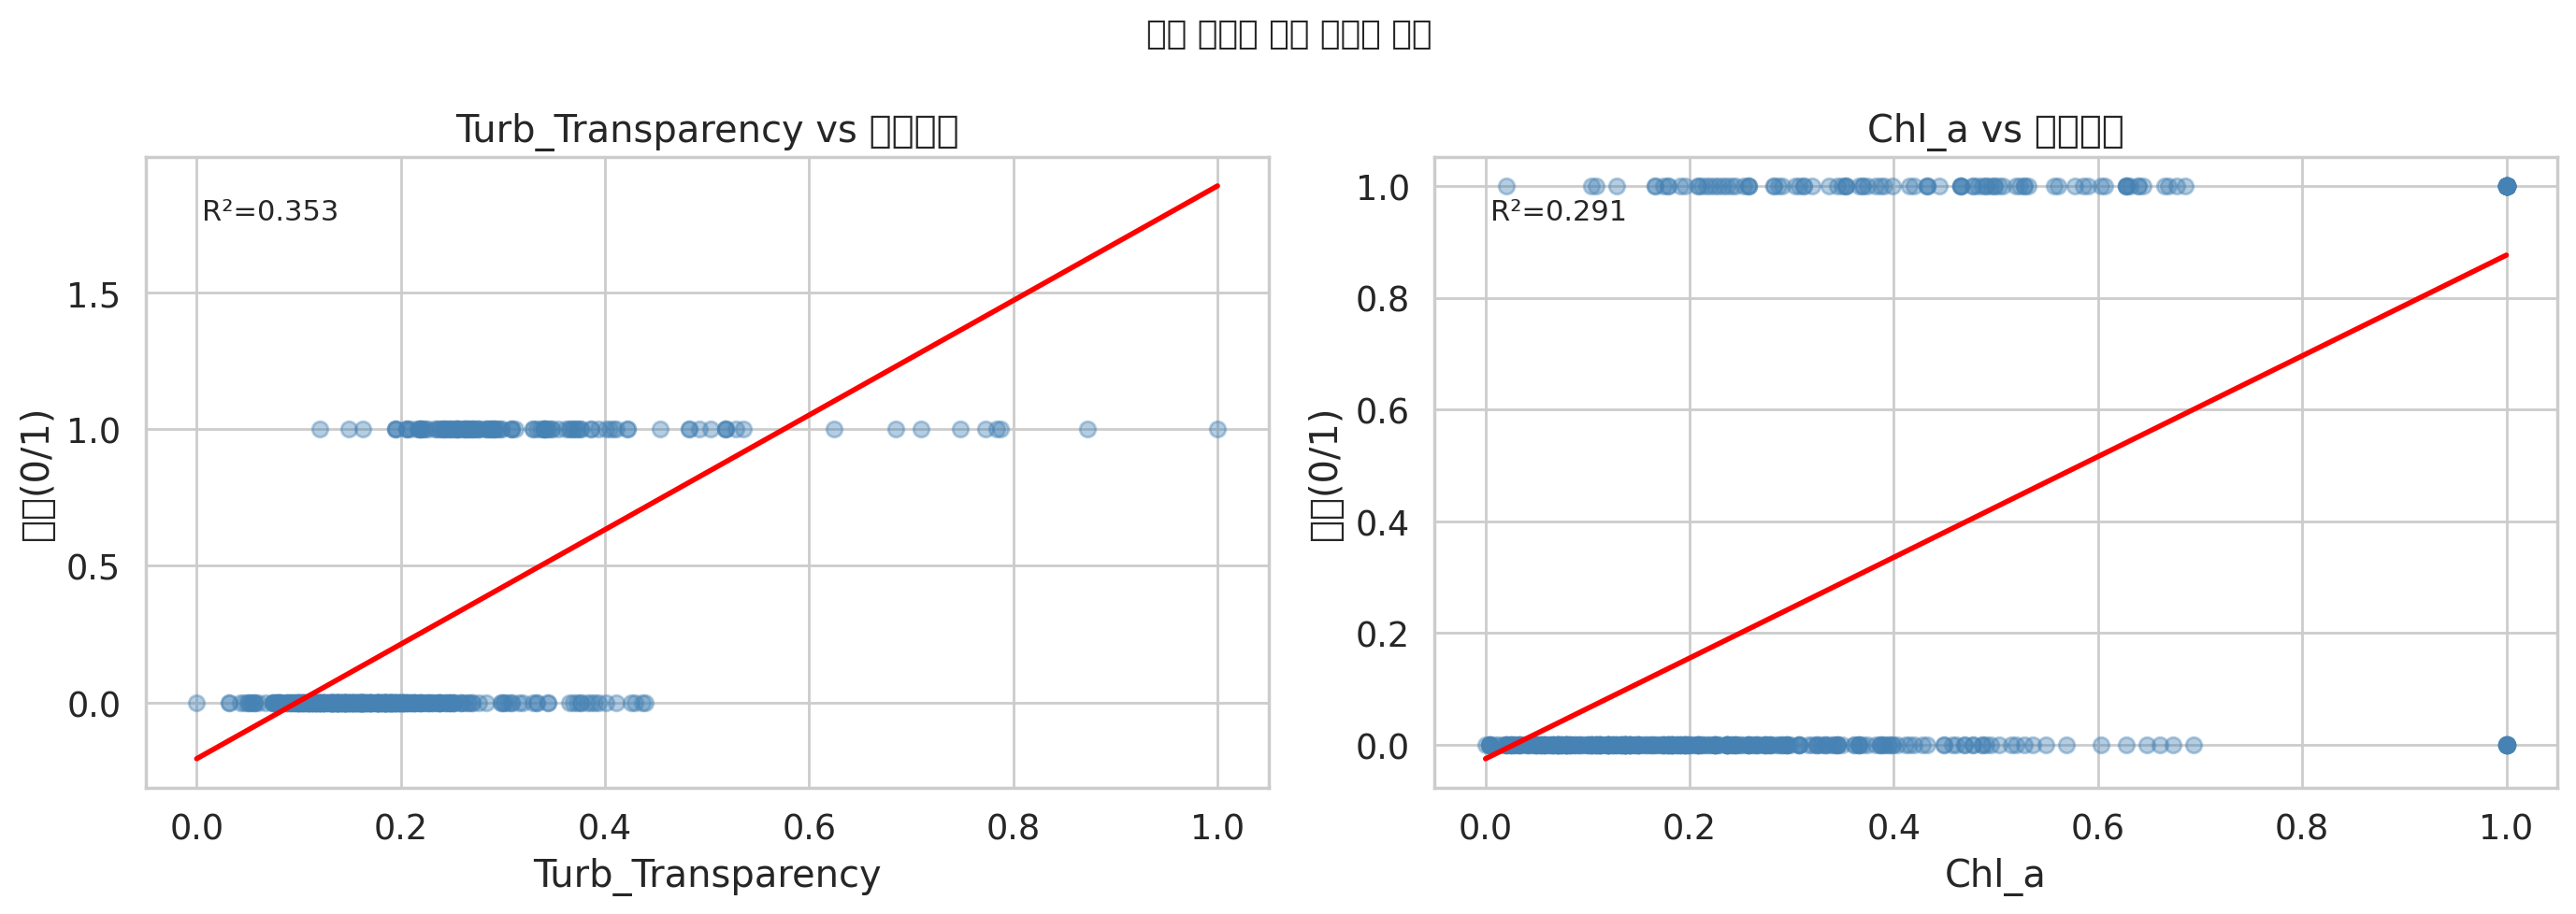

In [ ]:
# 8. 산점도 — Turb_Transparency vs newlabel
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('주요 변수와 조류 발령의 관계', fontsize=13)

for ax, col in zip(axes, ['Turb_Transparency', 'Chl_a']):
    ax.scatter(df_norm[col], df_norm['newlabel'], alpha=0.4, color='steelblue')
    X_r = df_norm[[col]].values
    y_r = df_norm['newlabel'].values
    reg = LinearRegression().fit(X_r, y_r)
    ax.plot(sorted(X_r), reg.predict(sorted(X_r)), color='red', lw=2)
    r2 = reg.score(X_r, y_r)
    ax.text(0.05, 0.9, f'R²={r2:.3f}', transform=ax.transAxes, fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('발령(0/1)')
    ax.set_title(f'{col} vs 발령여부')

plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/04_scatter.png', dpi=150, bbox_inches='tight')
plt.close()

In [ ]:
# 9. VIF (다중공선성) 확인
print("="*60)

FEATURE_COLS = ['WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency']

vif_data = df_norm[FEATURE_COLS].values
vif_df   = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'VIF Factor' : [variance_inflation_factor(vif_data, i)
                    for i in range(vif_data.shape[1])]
})
print(vif_df.to_string(index=False))

          Feature  VIF Factor
               WT    6.769795
               DO    1.858826
            Chl_a    3.389194
             Rain    1.990391
  Total_Discharge    1.541350
Turb_Transparency    7.478591


In [ ]:
import pandas as pd

# 10. Train / Test 분리 (시계열 → 마지막 20% holdout)
print("\n" + "="*60)
print("10. Train / Test 분리")
print("="*60)

X_data = df_norm[FEATURE_COLS].copy()
y_data = df_norm['newlabel'].shift(-1).copy() # Use df_norm for newlabel

# Drop the last row where y_data is NaN due to shift(-1)
X_data = X_data.iloc[:-1]
y_data = y_data.iloc[:-1]
dates_data = df_norm['Date'].iloc[:-1] # Also align dates

split_idx   = int(len(X_data) * 0.8) # Use X_data length for splitting
X_train_raw = X_data.iloc[:split_idx]
X_test      = X_data.iloc[split_idx:]
y_train_raw = y_data.iloc[:split_idx]
y_test      = y_data.iloc[split_idx:]

train_dates = dates_data.iloc[:split_idx]
test_dates  = dates_data.iloc[split_idx:]

print(f"  Train: {X_train_raw.shape[0]}행  ({train_dates.min().date()} ~ {train_dates.max().date()})")
print(f"  Test : {X_test.shape[0]}행   ({test_dates.min().date()} ~ {test_dates.max().date()})")
print(f"  Train 레이블: {y_train_raw.value_counts().to_dict()}")
print(f"  Test  레이블: {y_test.value_counts().to_dict()}")


10. Train / Test 분리
  Train: 411행  (2016-04-04 ~ 2024-03-25)
  Test : 103행   (2024-04-01 ~ 2025-12-15)
  Train 레이블: {0.0: 335, 1.0: 76}
  Test  레이블: {0.0: 56, 1.0: 47}


In [ ]:
# 11. StratifiedKFold → 마지막 fold train 사용 → RandomOverSampler
print("\n" + "="*60)
print("11. StratifiedKFold + RandomOverSampler")
print("="*60)

NUM_FOLDS = 5
stratkf   = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

X_train_fold = y_train_fold = None
for train_idx, val_idx in stratkf.split(X_train_raw, y_train_raw):
    X_train_fold = X_train_raw.iloc[train_idx]
    y_train_fold = y_train_raw.iloc[train_idx]

rus = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = rus.fit_resample(X_train_fold, y_train_fold)
print(f"  오버샘플링 전 클래스: {y_train_fold.value_counts().to_dict()}")
print(f"  오버샘플링 후 클래스: {pd.Series(y_resampled).value_counts().to_dict()}")


11. StratifiedKFold + RandomOverSampler
  오버샘플링 전 클래스: {0.0: 268, 1.0: 61}
  오버샘플링 후 클래스: {0.0: 268, 1.0: 268}


In [ ]:
# 12. XGBClassifier + GridSearchCV
print("\n" + "="*60)
print("12. XGBClassifier + GridSearchCV")
print("="*60)

xgb_clf = XGBClassifier(random_state=SEED, eval_metric='logloss',
                        use_label_encoder=False)

param_grid = {
    'learning_rate'   : [0.1, 0.3],
    'max_depth'       : [3, 5],
    'min_child_weight': [1, 3],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator  = xgb_clf,
    param_grid = param_grid,
    scoring    = 'accuracy',
    cv         = stratkf,
    verbose    = 1,
    n_jobs     = -1,
)
grid_search.fit(X_resampled, y_resampled)

best_model = grid_search.best_estimator_
print(f"\n  최적 하이퍼파라미터: {grid_search.best_params_}")
print(f"  교차검증 최고 정확도: {grid_search.best_score_:.4f}")


12. XGBClassifier + GridSearchCV
Fitting 5 folds for each of 32 candidates, totalling 160 fits

  최적 하이퍼파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
  교차검증 최고 정확도: 0.9608


In [ ]:
#13. 테스트 평가
print("\n" + "="*60)
print("13. 테스트 세트 평가")
print("="*60)

y_pred   = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"  테스트 정확도: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\n  분류 보고서:")
print(classification_report(y_test, y_pred,
                             target_names=['미발령(0)', '발령(1)']))

# 예측 비교 테이블
comp_df = pd.DataFrame({
    'Date'     : test_dates.values,
    'Actual'   : y_test.values,
    'Predicted': y_pred,
})
print("\n  실제값 vs 예측값 (처음 10개):")
print(comp_df.head(10).to_string(index=False))


13. 테스트 세트 평가
  테스트 정확도: 0.8738 (87.38%)

  분류 보고서:
              precision    recall  f1-score   support

      미발령(0)       0.84      0.95      0.89        56
       발령(1)       0.93      0.79      0.85        47

    accuracy                           0.87       103
   macro avg       0.88      0.87      0.87       103
weighted avg       0.88      0.87      0.87       103


  실제값 vs 예측값 (처음 10개):
      Date  Actual  Predicted
2024-04-01     0.0          0
2024-04-08     0.0          0
2024-04-15     0.0          0
2024-04-22     0.0          0
2024-04-29     0.0          0
2024-05-07     0.0          0
2024-05-13     0.0          0
2024-05-20     0.0          0
2024-05-27     0.0          0
2024-06-03     0.0          0


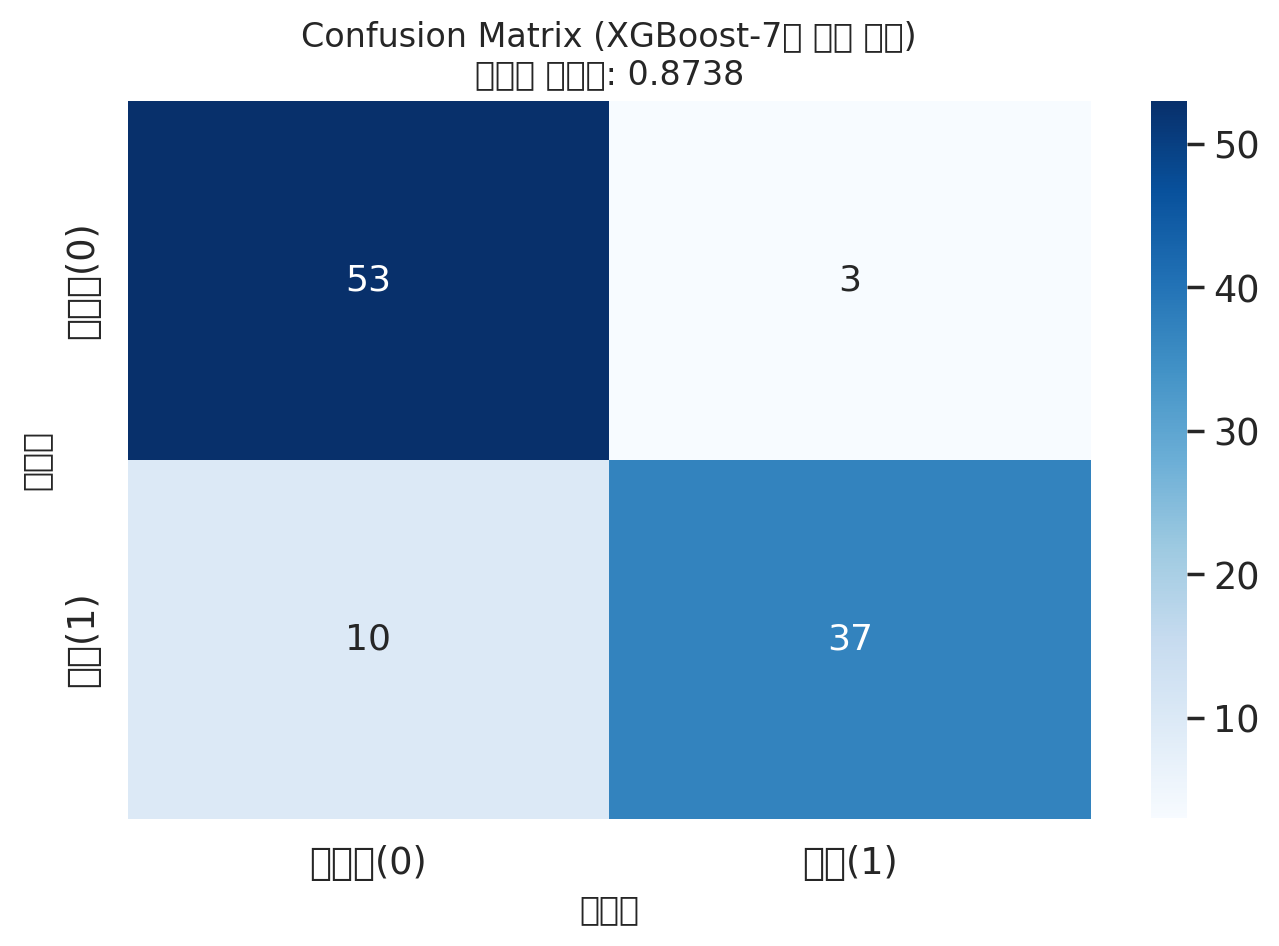

In [ ]:
# 14. Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['미발령(0)', '발령(1)'],
            yticklabels=['미발령(0)', '발령(1)'],
            annot_kws={'size': 13})
plt.xlabel('예측값', fontsize=12)
plt.ylabel('실제값', fontsize=12)
plt.title(f'Confusion Matrix (XGBoost-7일 선행 예측)\n테스트 정확도: {accuracy:.4f}',
          fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

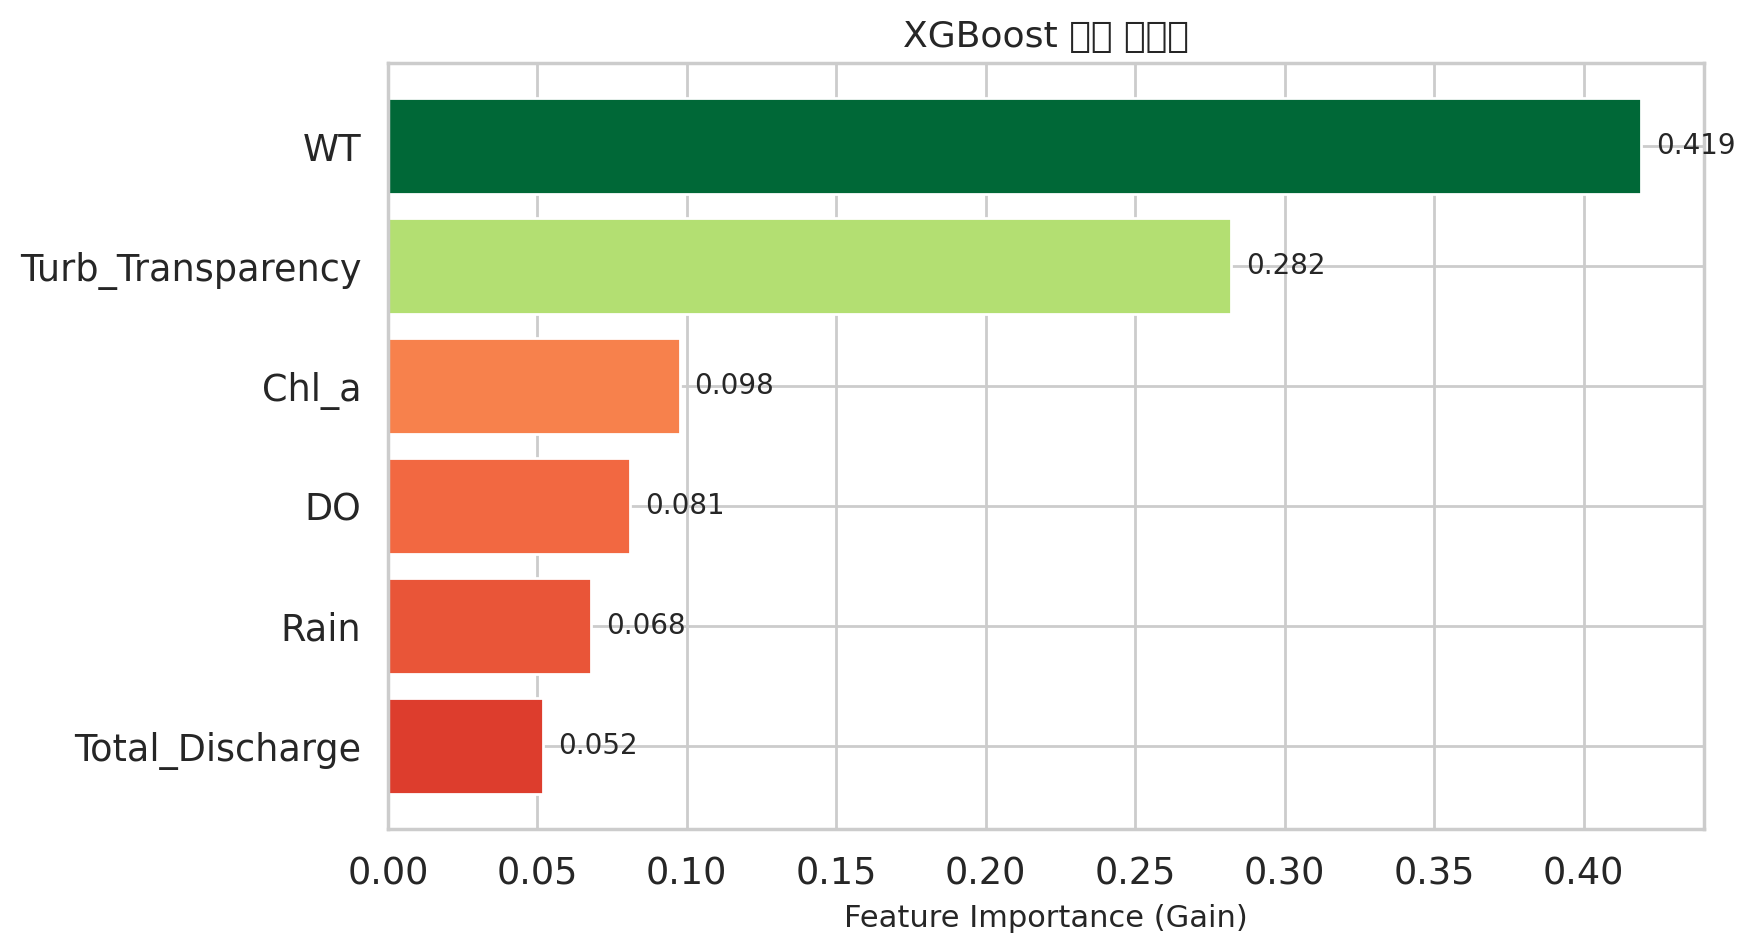

In [ ]:
# 15. Feature Importance 시각화
fi = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': fi}) \
          .sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=plt.cm.RdYlGn(fi_df['Importance'] / fi_df['Importance'].max()))
plt.xlabel('Feature Importance (Gain)', fontsize=11)
plt.title('XGBoost 특성 중요도', fontsize=13)
for bar, val in zip(bars, fi_df['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()
plt.savefig(f'{OUTPUT_DIR}/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()

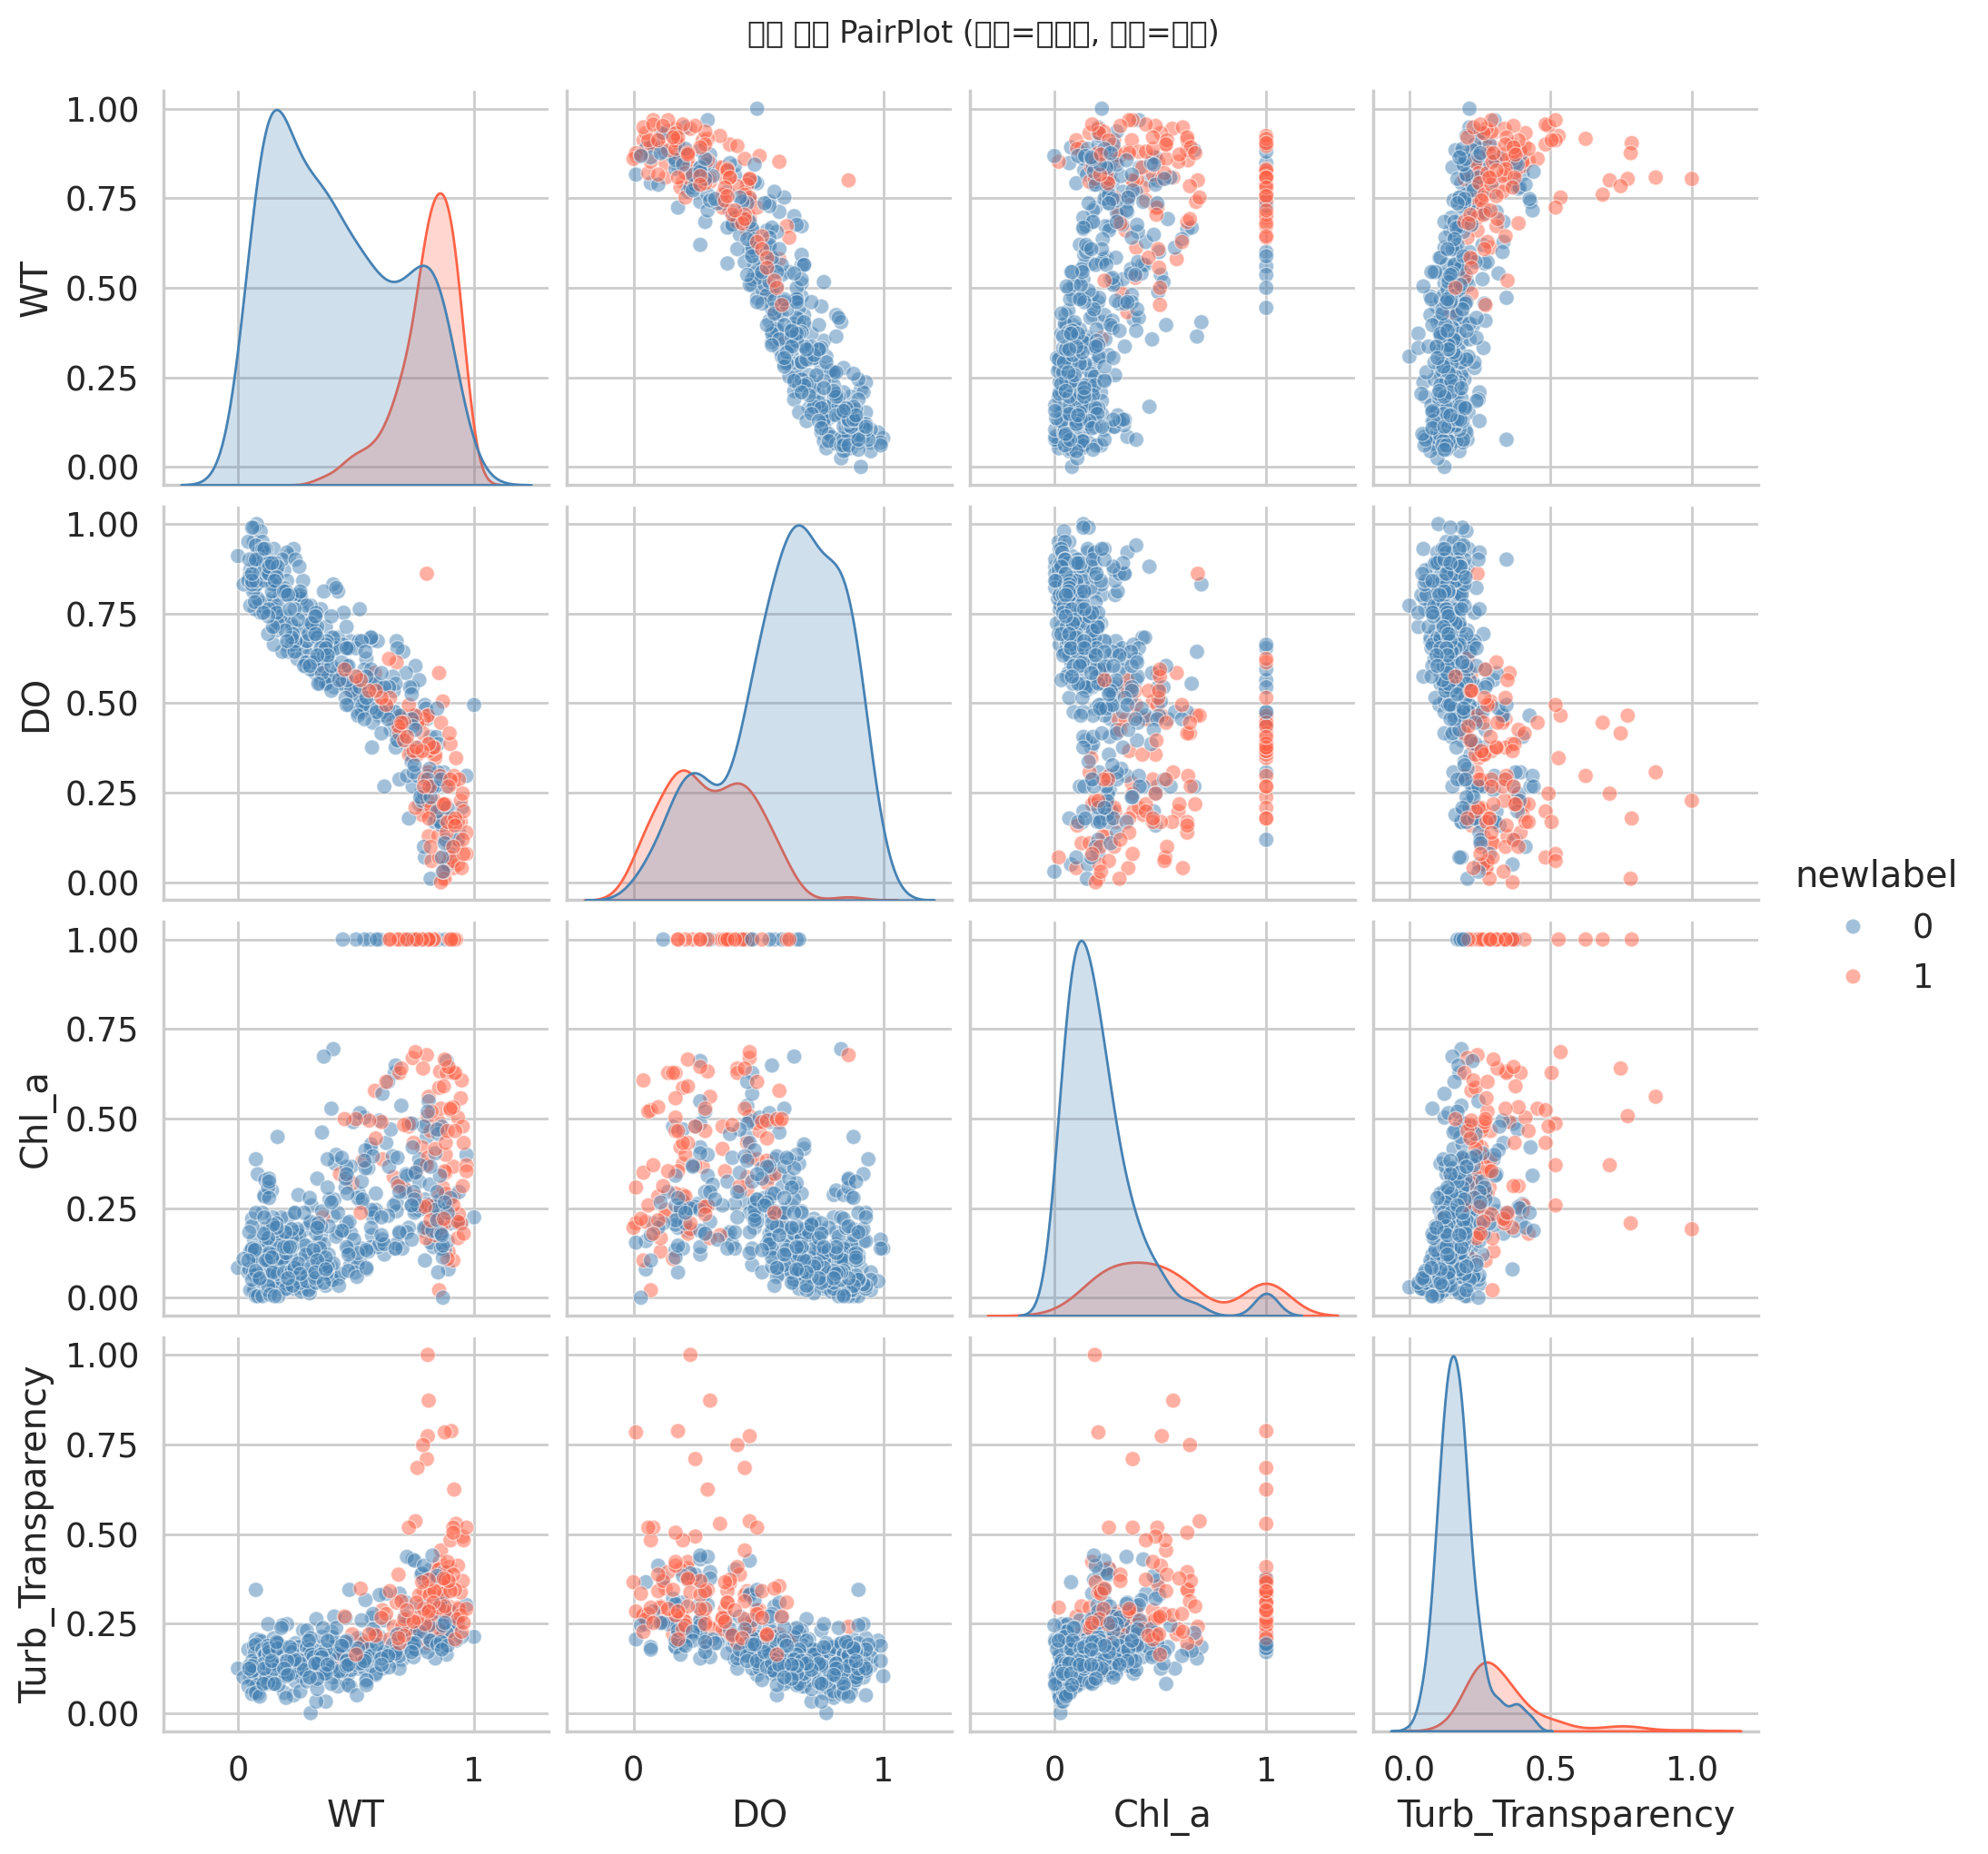

In [ ]:
# 16. PairGrid (변수 간 상관성 & 발령 구분)
pairplot_cols = ['WT', 'DO', 'Chl_a', 'Turb_Transparency', 'newlabel']
pairplot_cols = [c for c in pairplot_cols if c in df_norm.columns]

pp = sns.pairplot(df_norm[pairplot_cols], hue='newlabel',
                  plot_kws={'alpha': 0.5},
                  palette={0: 'steelblue', 1: 'tomato'})
pp.fig.suptitle('주요 변수 PairPlot (파란=미발령, 빨강=발령)', y=1.02, fontsize=12)
plt.show()
pp.fig.savefig(f'{OUTPUT_DIR}/07_pairplot.png', dpi=120, bbox_inches='tight')
plt.close()

In [ ]:
# 17. 결과 요약
print("\n" + "="*60)
print("최종 결과 요약")
print("="*60)
print(f"  데이터: 대청호 추동 지점  ({df.shape[0]}개 주간 관측값)")
print(f"  특성 ({len(FEATURE_COLS)}개): {FEATURE_COLS}")
print(f"  타겟: 이진 분류 (0=미발령, 1=관심+경계+대발생)")
print(f"  모델: XGBClassifier (GridSearchCV + StratifiedKFold-{NUM_FOLDS})")
print(f"  최적 파라미터: {grid_search.best_params_}")
print(f"  교차검증 정확도: {grid_search.best_score_:.4f}")
print(f"  테스트 정확도:   {accuracy:.4f}")
print(f"  중요 특성 Top3: {fi_df.sort_values('Importance',ascending=False)['Feature'].head(3).tolist()}")
print("\n  생성된 파일:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    if fn.endswith('.png') or fn.endswith('.py'):
        print(f"    {fn}")


최종 결과 요약
  데이터: 대청호 추동 지점  (515개 주간 관측값)
  특성 (6개): ['WT', 'DO', 'Chl_a', 'Rain', 'Total_Discharge', 'Turb_Transparency']
  타겟: 이진 분류 (0=미발령, 1=관심+경계+대발생)
  모델: XGBClassifier (GridSearchCV + StratifiedKFold-5)
  최적 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
  교차검증 정확도: 0.9608
  테스트 정확도:   0.8738
  중요 특성 Top3: ['WT', 'Turb_Transparency', 'Chl_a']

  생성된 파일:
    01_timeseries.png
    02_outlier_before.png
    03_correlation_heatmap.png
    04_scatter.png
    05_confusion_matrix.png
    06_feature_importance.png
    07_pairplot.png
